# ETF (QQQ) Daily Return Prediction — Multi-Model Comparison

> **Target**: Daily Return (%) of QQQ ETF  
> **Period**: 2014-01-02 ~ 2025-12-31  
> **Text Representations**: TF-IDF, FinBERT  
> **Financial Features**: Gold, Oil, Bond, CAD, CNY, EUR, JPY, MXN, VIX, Bitcoin (daily returns)  
> **Models**: 15+ models including Baselines, Tree-based, LSTM, Transformer, Ensemble

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os, re, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import torch
torch.manual_seed(SEED)

# NLTK setup
import nltk
local_nltk_dir = os.path.join(os.getcwd(), 'nltk_data')
nltk.data.path.insert(0, local_nltk_dir)
for pkg in ['stopwords', 'wordnet']:
    try:
        nltk.data.find('corpora/' + pkg)
    except LookupError:
        nltk.download(pkg, download_dir=local_nltk_dir, quiet=True)

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
import lightgbm as lgb

# Deep Learning
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import (LSTM, Dense, Bidirectional, PReLU, Dropout,
                          Input, LayerNormalization, GlobalAveragePooling1D)
from keras.layers import MultiHeadAttention
from keras.callbacks import EarlyStopping

# FinBERT
from transformers import BertTokenizer, BertModel

# Plot settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("All imports successful.")

All imports successful.


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# TF-IDF
TFIDF_MAX_FEATURES = 500
TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.8

# FinBERT
FINBERT_PCA_DIM = 50
FINBERT_BATCH_SIZE = 64

# Sequence models
WINDOW_SIZE = 20
SEQ_PCA_DIM = 50   # PCA dim for TF-IDF in sequence models

# Training
LSTM_EPOCHS    = 200
LSTM_BATCH     = 64
LSTM_PATIENCE  = 15
TRANS_EPOCHS   = 200
TRANS_BATCH    = 64
TRANS_PATIENCE = 15
TRANS_HEADS    = 4
TRANS_FF_DIM   = 64

# Financial feature columns (in US_research.csv)
FINANCIAL_COLS = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'vix', 'bitcoin']
TARGET_COL = 'Return'

# Output
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


In [3]:
# ============================================================
# UTILITY FUNCTIONS
# ============================================================
results_list = []
predictions_dict = {}         # model_name -> test predictions
val_predictions_dict = {}     # model_name -> val predictions
training_histories = {}       # model_name -> history dict
feature_importances_dict = {} # model_name -> (names, values)

def record_result(model_name, text_rep, y_true, y_pred,
                  y_val_true=None, y_val_pred=None):
    """Compute metrics and store results."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Direction Accuracy: % of correctly predicted return sign
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred))

    row = {'Model': model_name, 'Text_Rep': text_rep,
           'RMSE': rmse, 'MAE': mae, 'Dir_Acc': dir_acc, 'R2': r2}

    if y_val_true is not None and y_val_pred is not None:
        row['Val_RMSE'] = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
        val_predictions_dict[model_name] = np.asarray(y_val_pred).flatten()

    results_list.append(row)
    predictions_dict[model_name] = np.asarray(y_pred).flatten()

    print(f"  [{model_name}] RMSE={rmse:.6f} | MAE={mae:.6f} | "
          f"Dir_Acc={dir_acc:.4f} | R2={r2:.4f}")
    return row


def create_sequences(X, y, window):
    """Create overlapping window sequences for time-series models."""
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


def temporal_split_indices(n, train_r=0.70, val_r=0.15):
    """Return (train_end, val_end) indices for chronological split."""
    train_end = int(n * train_r)
    val_end   = int(n * (train_r + val_r))
    return train_end, val_end


def split_sequences(X_seq, y_seq, n_train, n_val, window):
    """Split pre-built sequences into train/val/test respecting time order.
    After create_sequences, index k predicts target at original position k+window.
    Train targets: positions window .. n_train-1   -> seq indices 0 .. n_train-window-1
    Val targets  : positions n_train .. n_train+n_val-1 -> next n_val
    Test targets : remainder
    """
    tr_end = n_train - window
    va_end = tr_end + n_val
    return (X_seq[:tr_end], y_seq[:tr_end],
            X_seq[tr_end:va_end], y_seq[tr_end:va_end],
            X_seq[va_end:], y_seq[va_end:])


def create_sequences_per_split(X_train, y_train, X_val, y_val, X_test, y_test, window):
    """Build sequences separately for each split to prevent boundary contamination.
    For val/test, uses the last 'window' rows of the previous split as burn-in context.
    This avoids future information leaking across split boundaries.
    """
    # Train: pure sequences within training data
    X_tr_seq, y_tr_seq = create_sequences(X_train, y_train, window)

    # Val: prepend last 'window' rows of train as context
    X_val_ext = np.vstack([X_train[-window:], X_val])
    y_val_ext = np.concatenate([y_train[-window:], y_val])
    X_va_seq, y_va_seq = create_sequences(X_val_ext, y_val_ext, window)

    # Test: prepend last 'window' rows of val as context
    X_test_ext = np.vstack([X_val[-window:], X_test])
    y_test_ext = np.concatenate([y_val[-window:], y_test])
    X_te_seq, y_te_seq = create_sequences(X_test_ext, y_test_ext, window)

    return (X_tr_seq, y_tr_seq, X_va_seq, y_va_seq, X_te_seq, y_te_seq)


def build_bilstm(input_shape, units=128):
    """Build a Bidirectional LSTM model."""
    model = Sequential([
        Bidirectional(LSTM(units, return_sequences=False),
                      input_shape=input_shape),
        Dense(128), PReLU(),
        Dropout(0.2),
        Dense(64), PReLU(),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_transformer(input_shape, num_heads=4, ff_dim=64, num_blocks=2):
    """Build a Transformer Encoder model for time-series."""
    inputs = Input(shape=input_shape)
    x = Dense(ff_dim)(inputs)

    for _ in range(num_blocks):
        attn = MultiHeadAttention(
            num_heads=num_heads, key_dim=ff_dim // num_heads)(x, x)
        x = LayerNormalization()(x + attn)
        ff = Dense(ff_dim * 2, activation='relu')(x)
        ff = Dropout(0.1)(ff)
        ff = Dense(ff_dim)(ff)
        x = LayerNormalization()(x + ff)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64)(x)
    x = PReLU()(x)
    x = Dropout(0.2)(x)
    x = Dense(32)(x)
    x = PReLU()(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def train_nn(model, X_tr, y_tr, X_va, y_va,
             epochs=200, batch=64, patience=15, name='model'):
    """Train a Keras model with EarlyStopping, return history dict."""
    es = EarlyStopping(monitor='val_loss', patience=patience,
                       restore_best_weights=True, verbose=0)
    t0 = time.time()
    hist = model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch,
                     validation_data=(X_va, y_va), callbacks=[es], verbose=0)
    elapsed = time.time() - t0
    print(f"  {name}: {len(hist.history['loss'])} epochs in {elapsed:.1f}s")
    training_histories[name] = {
        'loss': hist.history['loss'],
        'val_loss': hist.history['val_loss']
    }
    return hist

print("Utility functions defined.")

Utility functions defined.


## 1. Data Loading & Preprocessing

In [4]:
# ============================================================
# 1-1. Load Data & Compute Returns
# ============================================================
df = pd.read_csv("US_research.csv", encoding="utf-8")

# Clean columns
for drop_col in ['Unnamed: 0', 'Index']:
    if drop_col in df.columns:
        df.drop(columns=drop_col, inplace=True)

df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')
df = df.dropna(subset=['Date', 'ETF']).sort_values('Date').reset_index(drop=True)

# === CRITICAL FIX: Remove non-trading days (weekends & holidays) ===
# Weekend/holiday rows have zero returns and inflate R² artificially.
n_before = len(df)
df = df[df['Date'].dt.weekday < 5].reset_index(drop=True)  # Remove weekends
# Also remove rows where ETF price didn't change (holidays with carried-over price)
df = df[df['ETF'].diff().abs() > 1e-10].reset_index(drop=True)
n_after = len(df)
print(f"Removed {n_before - n_after} non-trading-day rows ({100*(n_before-n_after)/n_before:.1f}%)")

# Normalize VIX column name
if 'VIX' in df.columns and 'vix' not in df.columns:
    df.rename(columns={'VIX': 'vix'}, inplace=True)

# === Compute daily return as target ===
df['Return'] = df['ETF'].pct_change()

# === t-1 lag for news (Experiment A: true prediction) ===
df['Headline'] = df['Headline'].shift(1).fillna('')

# === Compute financial feature returns/changes (stationarity) ===
fin_return_cols = []
for col in FINANCIAL_COLS:
    if col in df.columns:
        if col == 'vix':
            # VIX: use first-difference (level change), not pct_change
            rc = col + '_chg'
            df[rc] = df[col].diff()
        elif col == 'bond':
            # Bond yield: use yield change (first-difference), not return
            rc = col + '_chg'
            df[rc] = df[col].diff()
        else:
            rc = col + '_ret'
            df[rc] = df[col].pct_change()
        df[rc] = df[rc].shift(1)  # === t-1 lag for TRUE PREDICTION (Experiment A) ===
        fin_return_cols.append(rc)

# ============================================================
# Autoregressive & Rolling Features
# ============================================================
for lag in range(1, 6):
    col_name = f'return_lag{lag}'
    df[col_name] = df['Return'].shift(lag)
    fin_return_cols.append(col_name)
print(f"Added return_lag1 ~ return_lag5")

df['rolling_ret_5d']  = df['Return'].rolling(5).mean().shift(1)
df['rolling_ret_20d'] = df['Return'].rolling(20).mean().shift(1)
df['rolling_vol_5d']  = df['Return'].rolling(5).std().shift(1)
df['rolling_vol_20d'] = df['Return'].rolling(20).std().shift(1)
fin_return_cols.extend(['rolling_ret_5d', 'rolling_ret_20d', 'rolling_vol_5d', 'rolling_vol_20d'])
print(f"Added rolling return means (5d/20d) and rolling volatility (5d/20d)")

# Drop rows with NaN from pct_change and rolling windows
df = df.dropna().reset_index(drop=True)

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df['Date'].min().date()} ~ {df['Date'].max().date()}")
print(f"Return stats  : mean={df['Return'].mean():.6f}, std={df['Return'].std():.4f}")
print(f"Feature cols ({len(fin_return_cols)}): {fin_return_cols}")
df.head()

Removed 1371 non-trading-day rows (31.3%)
Added return_lag1 ~ return_lag5
Added rolling return means (5d/20d) and rolling volatility (5d/20d)
Dataset shape : (2990, 33)
Date range    : 2014-02-04 ~ 2025-12-31
Return stats  : mean=0.000758, std=0.0135
Feature cols (19): ['gold_ret', 'oil_ret', 'bond_chg', 'cad_ret', 'cny_ret', 'eur_ret', 'jpy_ret', 'mxn_ret', 'vix_chg', 'bitcoin_ret', 'return_lag1', 'return_lag2', 'return_lag3', 'return_lag4', 'return_lag5', 'rolling_ret_5d', 'rolling_ret_20d', 'rolling_vol_5d', 'rolling_vol_20d']


,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,...,bitcoin_ret,return_lag1,return_lag2,return_lag3,return_lag4,return_lag5,rolling_ret_5d,rolling_ret_20d,rolling_vol_5d,rolling_vol_20d
0,2014-02-04,ARM Reports Loss as Sales of High-End Smartpho...,1251.2,97.19,2.631,1.1081,6.0610,0.7397,101.64,13.3173,...,-0.005474,-0.022942,-0.002671,0.018573,-0.010767,-0.000585,-0.003678,-0.001316,0.015224,0.011055
1,2014-02-05,"Disney Reports Strong First-Quarter Earnings, ...",1256.9,97.38,2.669,1.1082,6.0610,0.7389,101.43,13.2870,...,-0.023851,0.007271,-0.022942,-0.002671,0.018573,-0.010767,-0.002107,-0.000767,0.016008,0.011202
2,2014-02-06,Magazines Gain in Digital Sales but Newsstand ...,1257.2,97.84,2.702,1.1068,6.0610,0.7358,102.08,13.2729,...,-0.083582,-0.002485,0.007271,-0.022942,-0.002671,0.018573,-0.000451,-0.001351,0.015301,0.010957
3,2014-02-07,A Homegrown Comic Con Highlights Growth in Loc...,1262.9,99.88,2.684,1.1031,6.0634,0.7334,102.33,13.2852,...,-0.160695,0.012693,-0.002485,0.007271,-0.022942,-0.002671,-0.001627,-0.000826,0.013605,0.011379
4,2014-02-10,Icahn Ends Call for Apple Stock Buyback,1274.7,100.06,2.669,1.1054,6.0594,0.7328,102.24,13.3239,...,-0.162570,0.017805,0.012693,-0.002485,0.007271,-0.022942,0.002468,0.000231,0.016070,0.012093


In [5]:
# ============================================================
# 1-2. Text Preprocessing
# ============================================================
stop_words = set(stopwords.words('english'))
tok_re = RegexpTokenizer(r"[a-zA-Z]+")
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = re.sub("[^a-zA-Z]", " ", str(text).lower())
    tokens = tok_re.tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    # Use lemmatization only (stemming before lemmatization is redundant and harmful)
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

df['Headline_clean'] = df['Headline'].apply(preprocess_text)
print(f"Sample cleaned: {df['Headline_clean'].iloc[5][:80]}...")

Sample cleaned: west bank settlement israeli job double edged sword...


In [6]:
# ============================================================
# 1-3. Temporal Train / Val / Test Split
# ============================================================
n = len(df)
train_end, val_end = temporal_split_indices(n, TRAIN_RATIO, VAL_RATIO)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Train : {len(train_df)} rows  ({train_df['Date'].iloc[0].date()} ~ {train_df['Date'].iloc[-1].date()})")
print(f"Val   : {len(val_df)} rows  ({val_df['Date'].iloc[0].date()} ~ {val_df['Date'].iloc[-1].date()})")
print(f"Test  : {len(test_df)} rows  ({test_df['Date'].iloc[0].date()} ~ {test_df['Date'].iloc[-1].date()})")

# Scale financial features: fit on TRAIN only
scaler = StandardScaler()
scaler.fit(train_df[fin_return_cols])

X_train_fin = scaler.transform(train_df[fin_return_cols])
X_val_fin   = scaler.transform(val_df[fin_return_cols])
X_test_fin  = scaler.transform(test_df[fin_return_cols])

y_train = train_df[TARGET_COL].values
y_val   = val_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values
test_dates = test_df['Date'].values

n_train = len(y_train)
n_val   = len(y_val)
n_test  = len(y_test)

print(f"\nX_train_fin: {X_train_fin.shape}  X_val: {X_val_fin.shape}  X_test: {X_test_fin.shape}")

Train : 2093 rows  (2014-02-04 ~ 2022-06-03)
Val   : 448 rows  (2022-06-06 ~ 2024-03-18)
Test  : 449 rows  (2024-03-19 ~ 2025-12-31)

X_train_fin: (2093, 19)  X_val: (448, 19)  X_test: (449, 19)


## 2. Feature Extraction (TF-IDF & FinBERT)

In [7]:
# ============================================================
# 2-1. TF-IDF Features
# ============================================================
tfidf_vec = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,
                            min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF)
tfidf_vec.fit(train_df['Headline_clean'])

tfidf_train = tfidf_vec.transform(train_df['Headline_clean']).toarray()
tfidf_val   = tfidf_vec.transform(val_df['Headline_clean']).toarray()
tfidf_test  = tfidf_vec.transform(test_df['Headline_clean']).toarray()

# Flat TF-IDF + Financial returns (for tree / linear models)
X_train_tfidf = np.hstack([tfidf_train, X_train_fin])
X_val_tfidf   = np.hstack([tfidf_val,   X_val_fin])
X_test_tfidf  = np.hstack([tfidf_test,  X_test_fin])

print(f"TF-IDF dims   : {tfidf_train.shape[1]}")
print(f"Combined flat  : {X_train_tfidf.shape[1]}  (TF-IDF {tfidf_train.shape[1]} + Financial {X_train_fin.shape[1]})")

TF-IDF dims   : 500
Combined flat  : 519  (TF-IDF 500 + Financial 19)


In [8]:
# ============================================================
# 2-2. FinBERT Embedding Extraction
# ============================================================
print("Loading FinBERT model from ../../USD/finbert ...")
bert_tokenizer = BertTokenizer.from_pretrained('../../USD/finbert')
bert_model = BertModel.from_pretrained('../../USD/finbert')
bert_model.eval()

def extract_finbert_embeddings(texts, batch_size=FINBERT_BATCH_SIZE):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        encoded = bert_tokenizer(batch, padding=True, truncation=True,
                                 max_length=128, return_tensors='pt')
        with torch.no_grad():
            out = bert_model(**encoded)
        cls = out.last_hidden_state[:, 0, :].numpy()
        embeddings.append(cls)
        if (i // batch_size) % 20 == 0:
            print(f"  {min(i + batch_size, len(texts))}/{len(texts)}")
    return np.vstack(embeddings)

print("Extracting train embeddings ...")
fb_train_raw = extract_finbert_embeddings(train_df['Headline'].values)
print("Extracting val embeddings ...")
fb_val_raw = extract_finbert_embeddings(val_df['Headline'].values)
print("Extracting test embeddings ...")
fb_test_raw = extract_finbert_embeddings(test_df['Headline'].values)

# PCA: fit on train only
pca_fb = PCA(n_components=FINBERT_PCA_DIM, random_state=SEED)
pca_fb.fit(fb_train_raw)

fb_train = pca_fb.transform(fb_train_raw)
fb_val   = pca_fb.transform(fb_val_raw)
fb_test  = pca_fb.transform(fb_test_raw)

print(f"FinBERT PCA: 768 -> {FINBERT_PCA_DIM}  (explained var: {pca_fb.explained_variance_ratio_.sum():.4f})")

# Flat FinBERT + Financial returns
X_train_fb = np.hstack([fb_train, X_train_fin])
X_val_fb   = np.hstack([fb_val,   X_val_fin])
X_test_fb  = np.hstack([fb_test,  X_test_fin])

print(f"Combined flat  : {X_train_fb.shape[1]}  (FinBERT {fb_train.shape[1]} + Financial {X_train_fin.shape[1]})")

Loading FinBERT model from ./finbert ...


Loading weights: 100%|█| 199/199 [00:00<00:00, 603.97it/s, Materializing param=
BertModel LOAD REPORT from: ./finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting train embeddings ...
  64/2093
  1344/2093
Extracting val embeddings ...
  64/448
Extracting test embeddings ...
  64/449
FinBERT PCA: 768 -> 50  (explained var: 0.8218)
Combined flat  : 69  (FinBERT 50 + Financial 19)


In [9]:
# ============================================================
# 2-2b. FinBERT Sentiment Probability Features
# ============================================================
# Use FinBERT's classification head for sentiment (positive/negative/neutral)
from transformers import BertForSequenceClassification
import torch.nn.functional as F

print("Loading FinBERT classification model for sentiment probabilities ...")
bert_cls_model = BertForSequenceClassification.from_pretrained('../../USD/finbert')
bert_cls_model.eval()

def extract_finbert_sentiment(texts, batch_size=FINBERT_BATCH_SIZE):
    """Extract 3-class sentiment probabilities from FinBERT."""
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        encoded = bert_tokenizer(batch, padding=True, truncation=True,
                                 max_length=128, return_tensors='pt')
        with torch.no_grad():
            out = bert_cls_model(**encoded)
        probs = F.softmax(out.logits, dim=-1).numpy()  # (batch, 3)
        all_probs.append(probs)
        if (i // batch_size) % 20 == 0:
            print(f"  sentiment: {min(i + batch_size, len(texts))}/{len(texts)}")
    return np.vstack(all_probs)

print("Extracting sentiment probabilities ...")
sent_train = extract_finbert_sentiment(train_df['Headline'].values)
sent_val   = extract_finbert_sentiment(val_df['Headline'].values)
sent_test  = extract_finbert_sentiment(test_df['Headline'].values)
print(f"Sentiment features shape: {sent_train.shape}  (positive/negative/neutral)")

# Combined: FinBERT embedding + Sentiment + Financial
X_train_fb_sent = np.hstack([fb_train, sent_train, X_train_fin])
X_val_fb_sent   = np.hstack([fb_val,   sent_val,   X_val_fin])
X_test_fb_sent  = np.hstack([fb_test,  sent_test,  X_test_fin])
print(f"FinBERT+Sent flat: {X_train_fb_sent.shape[1]}  (PCA {fb_train.shape[1]} + Sent 3 + Fin {X_train_fin.shape[1]})")

# Sentiment-only + Financial (for ablation)
X_train_sent = np.hstack([sent_train, X_train_fin])
X_val_sent   = np.hstack([sent_val,   X_val_fin])
X_test_sent  = np.hstack([sent_test,  X_test_fin])
print(f"Sent-only  flat  : {X_train_sent.shape[1]}  (Sent 3 + Fin {X_train_fin.shape[1]})")

Loading FinBERT classification model for sentiment probabilities ...


Loading weights: 100%|█| 201/201 [00:00<00:00, 317.17it/s, Materializing param=
BertForSequenceClassification LOAD REPORT from: ./finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting sentiment probabilities ...
  sentiment: 64/2093
  sentiment: 1344/2093
  sentiment: 64/448
  sentiment: 64/449
Sentiment features shape: (2093, 3)  (positive/negative/neutral)
FinBERT+Sent flat: 72  (PCA 50 + Sent 3 + Fin 19)
Sent-only  flat  : 22  (Sent 3 + Fin 19)


In [10]:
# ============================================================
# 2-3. Window Sequences for LSTM / Transformer
# ============================================================
# PCA on TF-IDF for sequence models (reduce 500 -> SEQ_PCA_DIM)
pca_tfidf_seq = PCA(n_components=SEQ_PCA_DIM, random_state=SEED)
pca_tfidf_seq.fit(tfidf_train)

tfidf_train_pca = pca_tfidf_seq.transform(tfidf_train)
tfidf_val_pca   = pca_tfidf_seq.transform(tfidf_val)
tfidf_test_pca  = pca_tfidf_seq.transform(tfidf_test)

# --- TF-IDF sequence features (boundary-safe) ---
X_tr_tfidf_flat = np.hstack([tfidf_train_pca, X_train_fin])
X_va_tfidf_flat = np.hstack([tfidf_val_pca,   X_val_fin])
X_te_tfidf_flat = np.hstack([tfidf_test_pca,  X_test_fin])

(X_tr_tfidf_s, y_tr_tfidf_s,
 X_va_tfidf_s, y_va_tfidf_s,
 X_te_tfidf_s, y_te_tfidf_s) = create_sequences_per_split(
    X_tr_tfidf_flat, y_train,
    X_va_tfidf_flat, y_val,
    X_te_tfidf_flat, y_test,
    WINDOW_SIZE)

print(f"TF-IDF sequences  : train {X_tr_tfidf_s.shape}, val {X_va_tfidf_s.shape}, test {X_te_tfidf_s.shape}")

# --- FinBERT sequence features (boundary-safe) ---
X_tr_fb_flat = np.hstack([fb_train, X_train_fin])
X_va_fb_flat = np.hstack([fb_val,   X_val_fin])
X_te_fb_flat = np.hstack([fb_test,  X_test_fin])

(X_tr_fb_s, y_tr_fb_s,
 X_va_fb_s, y_va_fb_s,
 X_te_fb_s, y_te_fb_s) = create_sequences_per_split(
    X_tr_fb_flat, y_train,
    X_va_fb_flat, y_val,
    X_te_fb_flat, y_test,
    WINDOW_SIZE)

print(f"FinBERT sequences : train {X_tr_fb_s.shape}, val {X_va_fb_s.shape}, test {X_te_fb_s.shape}")

# --- Financial-only sequences (for ablation, boundary-safe) ---
(X_tr_fin_s, y_tr_fin_s,
 X_va_fin_s, y_va_fin_s,
 X_te_fin_s, y_te_fin_s) = create_sequences_per_split(
    X_train_fin, y_train,
    X_val_fin, y_val,
    X_test_fin, y_test,
    WINDOW_SIZE)

print(f"Fin-only sequences: train {X_tr_fin_s.shape}, val {X_va_fin_s.shape}, test {X_te_fin_s.shape}")

# Verify test targets are aligned
assert len(y_te_tfidf_s) == n_test, f"TF-IDF seq test size mismatch: {len(y_te_tfidf_s)} vs {n_test}"
assert len(y_te_fb_s)    == n_test, f"FinBERT seq test size mismatch: {len(y_te_fb_s)} vs {n_test}"
print("\nTest target alignment verified.")

TF-IDF sequences  : train (2073, 20, 69), val (448, 20, 69), test (449, 20, 69)
FinBERT sequences : train (2073, 20, 69), val (448, 20, 69), test (449, 20, 69)
Fin-only sequences: train (2073, 20, 19), val (448, 20, 19), test (449, 20, 19)

Test target alignment verified.


## 3. Baseline Models

In [11]:
# ============================================================
# 3-1. Naive Forecast (previous day return = today's prediction)
# ============================================================
print("=" * 60)
print("BASELINE MODELS")
print("=" * 60)

# Naive: predict 0 (mean return ~ 0 for daily returns)
naive_pred_test = np.full_like(y_test, y_train.mean())
record_result("Naive (Mean)", "None", y_test, naive_pred_test)

# ============================================================
# 3-2. Linear Regression  (financial features only)
# ============================================================
lr = LinearRegression()
lr.fit(X_train_fin, y_train)
lr_val_pred  = lr.predict(X_val_fin)
lr_test_pred = lr.predict(X_test_fin)
record_result("Linear Regression", "None", y_test, lr_test_pred,
              y_val, lr_val_pred)

# ============================================================
# 3-3. SVR  (financial features only)
# ============================================================
svr = SVR(kernel='rbf', C=1.0, epsilon=0.001)
svr.fit(X_train_fin, y_train)
svr_val_pred  = svr.predict(X_val_fin)
svr_test_pred = svr.predict(X_test_fin)
record_result("SVR (RBF)", "None", y_test, svr_test_pred,
              y_val, svr_val_pred)

print("\nBaseline models done.")

BASELINE MODELS
  [Naive (Mean)] RMSE=0.013469 | MAE=0.008970 | Dir_Acc=0.5857 | R2=-0.0001
  [Linear Regression] RMSE=0.007972 | MAE=0.005948 | Dir_Acc=0.7817 | R2=0.6496
  [SVR (RBF)] RMSE=0.012304 | MAE=0.008383 | Dir_Acc=0.6771 | R2=0.1655

Baseline models done.


In [12]:
# ============================================================
# 3-4. ARIMA Baseline
# ============================================================
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

print("\n--- ARIMA Baseline ---")
try:
    # Fit ARIMA(1,0,1) on train returns
    arima_model = ARIMA(y_train, order=(1, 0, 1))
    arima_fit = arima_model.fit()
    # Forecast test period
    arima_pred = arima_fit.forecast(steps=n_test)
    record_result("ARIMA(1,0,1)", "None", y_test, arima_pred)
    print("  ARIMA baseline done.")
except Exception as e:
    print(f"  ARIMA failed: {e}")

# ============================================================
# 3-5. GARCH(1,1) Baseline
# ============================================================
print("\n--- GARCH Baseline ---")
try:
    # GARCH models variance, mean is constant
    am = arch_model(y_train * 100, vol='Garch', p=1, q=1, mean='ARX', lags=1)
    garch_fit = am.fit(disp='off')
    # Forecast: use conditional mean
    garch_fcast = garch_fit.forecast(horizon=1, start=len(y_train), reindex=False)
    # Walk-forward for test period
    garch_preds = []
    full_returns = np.concatenate([y_train, y_test]) * 100
    for t in range(n_test):
        train_slice = full_returns[:len(y_train) + t]
        am_t = arch_model(train_slice, vol='Garch', p=1, q=1, mean='ARX', lags=1)
        fit_t = am_t.fit(disp='off', show_warning=False)
        fc = fit_t.forecast(horizon=1)
        garch_preds.append(fc.mean.iloc[-1, 0] / 100)
    garch_preds = np.array(garch_preds)
    record_result("GARCH(1,1)", "None", y_test, garch_preds)
    print("  GARCH baseline done.")
except Exception as e:
    print(f"  GARCH failed: {e}")

# ============================================================
# 3-6. FinBERT Sentiment + LightGBM  (sentiment probs only)
# ============================================================
print("\n--- Sentiment-Only LightGBM ---")
lgb_sent = lgb.LGBMRegressor(
    n_estimators=200, max_depth=15, learning_rate=0.05,
    random_state=SEED, verbose=-1, n_jobs=-1)
lgb_sent.fit(X_train_sent, y_train,
             eval_set=[(X_val_sent, y_val)],
             callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_sent_test = lgb_sent.predict(X_test_sent)
lgb_sent_val  = lgb_sent.predict(X_val_sent)
record_result("Sentiment + LightGBM", "Sentiment", y_test, lgb_sent_test,
              y_val, lgb_sent_val)


--- ARIMA Baseline ---
  [ARIMA(1,0,1)] RMSE=0.013473 | MAE=0.008976 | Dir_Acc=0.5835 | R2=-0.0006
  ARIMA baseline done.

--- GARCH Baseline ---
  [GARCH(1,1)] RMSE=0.013436 | MAE=0.008930 | Dir_Acc=0.5768 | R2=0.0048
  GARCH baseline done.

--- Sentiment-Only LightGBM ---
  [Sentiment + LightGBM] RMSE=0.008422 | MAE=0.005967 | Dir_Acc=0.7884 | R2=0.6090


{'Model': 'Sentiment + LightGBM',
 'Text_Rep': 'Sentiment',
 'RMSE': np.float64(0.008422043550013891),
 'MAE': 0.005966912627102891,
 'Dir_Acc': np.float64(0.7884187082405345),
 'R2': 0.6089873147433655,
 'Val_RMSE': np.float64(0.010715241360892585)}

## 4. TF-IDF Based Models

In [13]:
# ============================================================
# 4-0. Hyperparameter Tuning via Optuna (TimeSeriesSplit CV)
# ============================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

tscv_tune = TimeSeriesSplit(n_splits=3)

def tune_rf(X, y, n_trials=30):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }
        scores = []
        for tr_idx, va_idx in tscv_tune.split(X):
            m = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
            m.fit(X[tr_idx], y[tr_idx])
            pred = m.predict(X[va_idx])
            scores.append(np.sqrt(mean_squared_error(y[va_idx], pred)))
        return np.mean(scores)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def tune_lgbm(X, y, n_trials=30):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        }
        scores = []
        for tr_idx, va_idx in tscv_tune.split(X):
            m = lgb.LGBMRegressor(**params, random_state=SEED, verbose=-1, n_jobs=-1)
            m.fit(X[tr_idx], y[tr_idx])
            pred = m.predict(X[va_idx])
            scores.append(np.sqrt(mean_squared_error(y[va_idx], pred)))
        return np.mean(scores)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

print("Tuning RF hyperparameters on TF-IDF features ...")
best_rf_params = tune_rf(X_train_tfidf, y_train)
print(f"  Best RF params: {best_rf_params}")

print("Tuning LightGBM hyperparameters on TF-IDF features ...")
best_lgbm_params = tune_lgbm(X_train_tfidf, y_train)
print(f"  Best LightGBM params: {best_lgbm_params}")

# Also tune Ridge alpha
from sklearn.linear_model import RidgeCV
ridge_cv = RidgeCV(alphas=[0.1, 1.0, 5.0, 10.0, 50.0, 100.0], cv=tscv_tune)
ridge_cv.fit(X_train_fb, y_train)
best_ridge_alpha = ridge_cv.alpha_
print(f"  Best Ridge alpha: {best_ridge_alpha}")

Tuning RF hyperparameters on TF-IDF features ...
  Best RF params: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1}
Tuning LightGBM hyperparameters on TF-IDF features ...
  Best LightGBM params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.02385090402173581, 'num_leaves': 49, 'subsample': 0.6117084187918973, 'colsample_bytree': 0.9226451492601743}
  Best Ridge alpha: 50.0


In [14]:
# ============================================================
# 4-1. TF-IDF + Random Forest
# ============================================================
print("=" * 60)
print("TF-IDF MODELS")
print("=" * 60)

rf_tfidf = RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1)
rf_tfidf.fit(X_train_tfidf, y_train)
print(f"  RF params: {best_rf_params}")

rf_val_pred  = rf_tfidf.predict(X_val_tfidf)
rf_test_pred = rf_tfidf.predict(X_test_tfidf)
record_result("TF-IDF + RF", "TF-IDF", y_test, rf_test_pred, y_val, rf_val_pred)

# Store feature importance
fi_names = [f"tfidf_{i}" for i in range(TFIDF_MAX_FEATURES)] + fin_return_cols
feature_importances_dict["TF-IDF + RF"] = (fi_names, rf_tfidf.feature_importances_)

TF-IDF MODELS
  RF params: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1}
  [TF-IDF + RF] RMSE=0.008114 | MAE=0.005781 | Dir_Acc=0.7884 | R2=0.6371


In [15]:
# ============================================================
# 4-2. TF-IDF + LightGBM
# ============================================================
lgb_tfidf = lgb.LGBMRegressor(**best_lgbm_params,
    random_state=SEED, verbose=-1, n_jobs=-1)
print(f"  LightGBM params: {best_lgbm_params}")
lgb_tfidf.fit(X_train_tfidf, y_train,
              eval_set=[(X_val_tfidf, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_val_pred  = lgb_tfidf.predict(X_val_tfidf)
lgb_test_pred = lgb_tfidf.predict(X_test_tfidf)
record_result("TF-IDF + LightGBM", "TF-IDF", y_test, lgb_test_pred, y_val, lgb_val_pred)

fi_names = [f"tfidf_{i}" for i in range(TFIDF_MAX_FEATURES)] + fin_return_cols
feature_importances_dict["TF-IDF + LightGBM"] = (fi_names, lgb_tfidf.feature_importances_)

  LightGBM params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.02385090402173581, 'num_leaves': 49, 'subsample': 0.6117084187918973, 'colsample_bytree': 0.9226451492601743}
  [TF-IDF + LightGBM] RMSE=0.008153 | MAE=0.005750 | Dir_Acc=0.7840 | R2=0.6336


In [16]:
# ============================================================
# 4-3. TF-IDF + BiLSTM  (window-based sequences)
# ============================================================
bilstm_tfidf = build_bilstm(
    input_shape=(WINDOW_SIZE, X_tr_tfidf_s.shape[2]), units=128)
train_nn(bilstm_tfidf, X_tr_tfidf_s, y_tr_tfidf_s,
         X_va_tfidf_s, y_va_tfidf_s,
         epochs=LSTM_EPOCHS, batch=LSTM_BATCH,
         patience=LSTM_PATIENCE, name="TF-IDF + BiLSTM")

bilstm_tfidf_val  = bilstm_tfidf.predict(X_va_tfidf_s, verbose=0).flatten()
bilstm_tfidf_test = bilstm_tfidf.predict(X_te_tfidf_s, verbose=0).flatten()
record_result("TF-IDF + BiLSTM", "TF-IDF", y_te_tfidf_s, bilstm_tfidf_test,
              y_va_tfidf_s, bilstm_tfidf_val)

  TF-IDF + BiLSTM: 30 epochs in 31.1s
  [TF-IDF + BiLSTM] RMSE=0.014242 | MAE=0.010290 | Dir_Acc=0.5122 | R2=-0.1182


{'Model': 'TF-IDF + BiLSTM',
 'Text_Rep': 'TF-IDF',
 'RMSE': np.float64(0.014242131615460844),
 'MAE': 0.010289579361639154,
 'Dir_Acc': np.float64(0.512249443207127),
 'R2': -0.11816494086095375,
 'Val_RMSE': np.float64(0.016109595027070215)}

In [17]:
# ============================================================
# 4-4. TF-IDF + Hybrid  (RF feature selection -> BiLSTM)
# ============================================================
# Step 1: RF to select top-K features from flat TF-IDF + fin
importances = rf_tfidf.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[-top_k:][::-1]
top_names = [fi_names[i] for i in top_idx]
print(f"Hybrid top-{top_k} features: {top_names[:10]}...")

# Step 2: Rebuild sequences with selected features only (boundary-safe)
X_tr_hyb_flat = X_train_tfidf[:, top_idx]
X_va_hyb_flat = X_val_tfidf[:, top_idx]
X_te_hyb_flat = X_test_tfidf[:, top_idx]

(X_tr_hyb, y_tr_hyb,
 X_va_hyb, y_va_hyb,
 X_te_hyb, y_te_hyb) = create_sequences_per_split(
    X_tr_hyb_flat, y_train,
    X_va_hyb_flat, y_val,
    X_te_hyb_flat, y_test,
    WINDOW_SIZE)

# Step 3: BiLSTM on selected features
bilstm_hybrid = build_bilstm(
    input_shape=(WINDOW_SIZE, top_k), units=128)
train_nn(bilstm_hybrid, X_tr_hyb, y_tr_hyb,
         X_va_hyb, y_va_hyb,
         epochs=LSTM_EPOCHS, batch=LSTM_BATCH,
         patience=LSTM_PATIENCE, name="TF-IDF + Hybrid(RF->BiLSTM)")

hyb_val  = bilstm_hybrid.predict(X_va_hyb, verbose=0).flatten()
hyb_test = bilstm_hybrid.predict(X_te_hyb, verbose=0).flatten()
record_result("TF-IDF + Hybrid(RF->BiLSTM)", "TF-IDF", y_te_hyb, hyb_test,
              y_va_hyb, hyb_val)

Hybrid top-20 features: ['vix_chg', 'rolling_ret_20d', 'rolling_ret_5d', 'rolling_vol_20d', 'rolling_vol_5d', 'return_lag1', 'return_lag5', 'gold_ret', 'bond_chg', 'return_lag2']...
  TF-IDF + Hybrid(RF->BiLSTM): 30 epochs in 21.8s
  [TF-IDF + Hybrid(RF->BiLSTM)] RMSE=0.014492 | MAE=0.010120 | Dir_Acc=0.5390 | R2=-0.1578


{'Model': 'TF-IDF + Hybrid(RF->BiLSTM)',
 'Text_Rep': 'TF-IDF',
 'RMSE': np.float64(0.014492440931502946),
 'MAE': 0.010119981074782947,
 'Dir_Acc': np.float64(0.5389755011135857),
 'R2': -0.15781443364142933,
 'Val_RMSE': np.float64(0.01582429103156916)}

## 5. FinBERT Based Models

In [18]:
# ============================================================
# 5-1. FinBERT + Ridge Regression
# ============================================================
print("=" * 60)
print("FINBERT MODELS")
print("=" * 60)

ridge_fb = Ridge(alpha=best_ridge_alpha)
print(f"  Ridge alpha: {best_ridge_alpha}")
ridge_fb.fit(X_train_fb, y_train)

ridge_val_pred  = ridge_fb.predict(X_val_fb)
ridge_test_pred = ridge_fb.predict(X_test_fb)
record_result("FinBERT + Ridge", "FinBERT", y_test, ridge_test_pred,
              y_val, ridge_val_pred)

# Store coefficient importance
fb_feat_names = [f"FB_PC{i}" for i in range(FINBERT_PCA_DIM)] + fin_return_cols
feature_importances_dict["FinBERT + Ridge"] = (
    fb_feat_names, np.abs(ridge_fb.coef_))

FINBERT MODELS
  Ridge alpha: 50.0
  [FinBERT + Ridge] RMSE=0.008194 | MAE=0.006128 | Dir_Acc=0.7639 | R2=0.6299


In [19]:
# ============================================================
# 5-2. FinBERT + LightGBM
# ============================================================
lgb_fb = lgb.LGBMRegressor(**best_lgbm_params,
    random_state=SEED, verbose=-1, n_jobs=-1)
lgb_fb.fit(X_train_fb, y_train,
           eval_set=[(X_val_fb, y_val)],
           callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_fb_val  = lgb_fb.predict(X_val_fb)
lgb_fb_test = lgb_fb.predict(X_test_fb)
record_result("FinBERT + LightGBM", "FinBERT", y_test, lgb_fb_test,
              y_val, lgb_fb_val)

feature_importances_dict["FinBERT + LightGBM"] = (
    fb_feat_names, lgb_fb.feature_importances_)

  [FinBERT + LightGBM] RMSE=0.008174 | MAE=0.005700 | Dir_Acc=0.7773 | R2=0.6317


In [20]:
# ============================================================
# 5-3. FinBERT + BiLSTM  (window-based sequences)
# ============================================================
bilstm_fb = build_bilstm(
    input_shape=(WINDOW_SIZE, X_tr_fb_s.shape[2]), units=128)
train_nn(bilstm_fb, X_tr_fb_s, y_tr_fb_s,
         X_va_fb_s, y_va_fb_s,
         epochs=LSTM_EPOCHS, batch=LSTM_BATCH,
         patience=LSTM_PATIENCE, name="FinBERT + BiLSTM")

bilstm_fb_val  = bilstm_fb.predict(X_va_fb_s, verbose=0).flatten()
bilstm_fb_test = bilstm_fb.predict(X_te_fb_s, verbose=0).flatten()
record_result("FinBERT + BiLSTM", "FinBERT", y_te_fb_s, bilstm_fb_test,
              y_va_fb_s, bilstm_fb_val)

  FinBERT + BiLSTM: 122 epochs in 119.7s
  [FinBERT + BiLSTM] RMSE=0.014893 | MAE=0.010353 | Dir_Acc=0.5323 | R2=-0.2227


{'Model': 'FinBERT + BiLSTM',
 'Text_Rep': 'FinBERT',
 'RMSE': np.float64(0.014893107053071872),
 'MAE': 0.010353302713348009,
 'Dir_Acc': np.float64(0.532293986636971),
 'R2': -0.22271855834574694,
 'Val_RMSE': np.float64(0.015106656160625832)}

## 6. Transformer Encoder Models

In [21]:
# ============================================================
# 6-1. TF-IDF + Transformer Encoder
# ============================================================
print("=" * 60)
print("TRANSFORMER MODELS")
print("=" * 60)

trans_tfidf = build_transformer(
    input_shape=(WINDOW_SIZE, X_tr_tfidf_s.shape[2]),
    num_heads=TRANS_HEADS, ff_dim=TRANS_FF_DIM, num_blocks=2)
train_nn(trans_tfidf, X_tr_tfidf_s, y_tr_tfidf_s,
         X_va_tfidf_s, y_va_tfidf_s,
         epochs=TRANS_EPOCHS, batch=TRANS_BATCH,
         patience=TRANS_PATIENCE, name="TF-IDF + Transformer")

trans_tfidf_val  = trans_tfidf.predict(X_va_tfidf_s, verbose=0).flatten()
trans_tfidf_test = trans_tfidf.predict(X_te_tfidf_s, verbose=0).flatten()
record_result("TF-IDF + Transformer", "TF-IDF", y_te_tfidf_s, trans_tfidf_test,
              y_va_tfidf_s, trans_tfidf_val)

TRANSFORMER MODELS
  TF-IDF + Transformer: 23 epochs in 30.2s
  [TF-IDF + Transformer] RMSE=0.013936 | MAE=0.009590 | Dir_Acc=0.4343 | R2=-0.0706


{'Model': 'TF-IDF + Transformer',
 'Text_Rep': 'TF-IDF',
 'RMSE': np.float64(0.013936019498130088),
 'MAE': 0.009589680150849956,
 'Dir_Acc': np.float64(0.43429844097995546),
 'R2': -0.0706151187466284,
 'Val_RMSE': np.float64(0.014444674934374993)}

In [22]:
# ============================================================
# 6-2. FinBERT + Transformer Encoder
# ============================================================
trans_fb = build_transformer(
    input_shape=(WINDOW_SIZE, X_tr_fb_s.shape[2]),
    num_heads=TRANS_HEADS, ff_dim=TRANS_FF_DIM, num_blocks=2)
train_nn(trans_fb, X_tr_fb_s, y_tr_fb_s,
         X_va_fb_s, y_va_fb_s,
         epochs=TRANS_EPOCHS, batch=TRANS_BATCH,
         patience=TRANS_PATIENCE, name="FinBERT + Transformer")

trans_fb_val  = trans_fb.predict(X_va_fb_s, verbose=0).flatten()
trans_fb_test = trans_fb.predict(X_te_fb_s, verbose=0).flatten()
record_result("FinBERT + Transformer", "FinBERT", y_te_fb_s, trans_fb_test,
              y_va_fb_s, trans_fb_val)

  FinBERT + Transformer: 31 epochs in 40.0s
  [FinBERT + Transformer] RMSE=0.013565 | MAE=0.009051 | Dir_Acc=0.5412 | R2=-0.0144


{'Model': 'FinBERT + Transformer',
 'Text_Rep': 'FinBERT',
 'RMSE': np.float64(0.013565390543885747),
 'MAE': 0.009051476456834701,
 'Dir_Acc': np.float64(0.5412026726057907),
 'R2': -0.014426263129742933,
 'Val_RMSE': np.float64(0.014111778747323238)}

## 7. Ensemble Models

In [23]:
# ============================================================
# 7-1. TF-IDF Stacking  (RF + LGB + Ridge -> Ridge meta)
# ============================================================
print("=" * 60)
print("ENSEMBLE MODELS")
print("=" * 60)

# KFold for stacking CV (TimeSeriesSplit not a partition; cross_val_predict requires partition)
stacking_cv = KFold(n_splits=5, shuffle=False)

stack_tfidf = StackingRegressor(
    estimators=[
        ('rf',    RandomForestRegressor(**best_rf_params,
                                        random_state=SEED, n_jobs=-1)),
        ('lgb',   lgb.LGBMRegressor(**best_lgbm_params,
                                     random_state=SEED,
                                     verbose=-1, n_jobs=-1)),
        ('ridge', Ridge(alpha=best_ridge_alpha)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=stacking_cv, n_jobs=1
)
print("Training TF-IDF Stacking ...")
stack_tfidf.fit(X_train_tfidf, y_train)

stk_tfidf_val  = stack_tfidf.predict(X_val_tfidf)
stk_tfidf_test = stack_tfidf.predict(X_test_tfidf)
record_result("TF-IDF + Stacking", "TF-IDF", y_test, stk_tfidf_test,
              y_val, stk_tfidf_val)

ENSEMBLE MODELS
Training TF-IDF Stacking ...
  [TF-IDF + Stacking] RMSE=0.010462 | MAE=0.007178 | Dir_Acc=0.7817 | R2=0.3966


{'Model': 'TF-IDF + Stacking',
 'Text_Rep': 'TF-IDF',
 'RMSE': np.float64(0.010462044749882228),
 'MAE': 0.007177578141145031,
 'Dir_Acc': np.float64(0.7817371937639198),
 'R2': 0.3966226155790805,
 'Val_RMSE': np.float64(0.012610324181193455)}

In [24]:
# ============================================================
# 7-2. FinBERT Stacking  (RF + LGB + Ridge -> Ridge meta)
# ============================================================
stack_fb = StackingRegressor(
    estimators=[
        ('rf',    RandomForestRegressor(**best_rf_params,
                                        random_state=SEED, n_jobs=-1)),
        ('lgb',   lgb.LGBMRegressor(**best_lgbm_params,
                                     random_state=SEED,
                                     verbose=-1, n_jobs=-1)),
        ('ridge', Ridge(alpha=best_ridge_alpha)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=stacking_cv, n_jobs=1
)
print("Training FinBERT Stacking ...")
stack_fb.fit(X_train_fb, y_train)

stk_fb_val  = stack_fb.predict(X_val_fb)
stk_fb_test = stack_fb.predict(X_test_fb)
record_result("FinBERT + Stacking", "FinBERT", y_test, stk_fb_test,
              y_val, stk_fb_val)

Training FinBERT Stacking ...
  [FinBERT + Stacking] RMSE=0.010494 | MAE=0.007189 | Dir_Acc=0.7929 | R2=0.3929


{'Model': 'FinBERT + Stacking',
 'Text_Rep': 'FinBERT',
 'RMSE': np.float64(0.01049394346644844),
 'MAE': 0.007189064986053674,
 'Dir_Acc': np.float64(0.7928730512249443),
 'R2': 0.3929376177469007,
 'Val_RMSE': np.float64(0.012637758457828772)}

In [25]:
# ============================================================
# 7-3. Weighted Blending  (top-3 models by val RMSE)
# ============================================================
# Build temporary results to find best 3
temp_df = pd.DataFrame(results_list)
if 'Val_RMSE' in temp_df.columns:
    valid_models = temp_df.dropna(subset=['Val_RMSE']).nsmallest(3, 'Val_RMSE')
else:
    valid_models = temp_df.nsmallest(3, 'RMSE')

print("Top-3 models for blending:")
print(valid_models[['Model', 'RMSE']].to_string(index=False))

blend_names = valid_models['Model'].tolist()
# Use inverse RMSE as weights
blend_rmses = valid_models['RMSE'].values
weights = (1.0 / blend_rmses)
weights = weights / weights.sum()
print(f"Weights: {dict(zip(blend_names, weights.round(4)))}")

# Blend test predictions
blend_test = np.zeros(n_test)
for name, w in zip(blend_names, weights):
    blend_test += w * predictions_dict[name][:n_test]

# Blend val predictions
blend_val = np.zeros(n_val)
for name, w in zip(blend_names, weights):
    if name in val_predictions_dict:
        blend_val += w * val_predictions_dict[name][:n_val]
    else:
        blend_val += w * np.zeros(n_val)

record_result("Weighted Blending (Top-3)", "Mixed", y_test, blend_test,
              y_val, blend_val)

Top-3 models for blending:
               Model     RMSE
Sentiment + LightGBM 0.008422
   TF-IDF + LightGBM 0.008153
  FinBERT + LightGBM 0.008174
Weights: {'Sentiment + LightGBM': np.float64(0.3264), 'TF-IDF + LightGBM': np.float64(0.3372), 'FinBERT + LightGBM': np.float64(0.3363)}
  [Weighted Blending (Top-3)] RMSE=0.008165 | MAE=0.005746 | Dir_Acc=0.7795 | R2=0.6325


{'Model': 'Weighted Blending (Top-3)',
 'Text_Rep': 'Mixed',
 'RMSE': np.float64(0.008164526798694234),
 'MAE': 0.005746446072142719,
 'Dir_Acc': np.float64(0.779510022271715),
 'R2': 0.6325333592916518,
 'Val_RMSE': np.float64(0.010700002340308752)}

## 8. Ablation Study — Effect of Text Features

In [26]:
# ============================================================
# 8. ABLATION: Financial-only vs Financial+Text
# ============================================================
print("=" * 60)
print("ABLATION STUDY (No Text Features)")
print("=" * 60)

ablation_results = []

# --- RF (Financial Only) ---
rf_fin = RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1)
rf_fin.fit(X_train_fin, y_train)
rf_fin_test = rf_fin.predict(X_test_fin)
r = record_result("RF (Fin Only)", "None", y_test, rf_fin_test)
ablation_results.append(r)

# --- LightGBM (Financial Only) ---
lgb_fin = lgb.LGBMRegressor(**best_lgbm_params,
    random_state=SEED, verbose=-1, n_jobs=-1)
lgb_fin.fit(X_train_fin, y_train,
            eval_set=[(X_val_fin, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_fin_test = lgb_fin.predict(X_test_fin)
r = record_result("LightGBM (Fin Only)", "None", y_test, lgb_fin_test)
ablation_results.append(r)

# --- BiLSTM (Financial Only, sequences) ---
bilstm_fin = build_bilstm(
    input_shape=(WINDOW_SIZE, X_tr_fin_s.shape[2]), units=64)
train_nn(bilstm_fin, X_tr_fin_s, y_tr_fin_s,
         X_va_fin_s, y_va_fin_s,
         epochs=LSTM_EPOCHS, batch=LSTM_BATCH,
         patience=LSTM_PATIENCE, name="BiLSTM (Fin Only)")
bilstm_fin_test = bilstm_fin.predict(X_te_fin_s, verbose=0).flatten()
r = record_result("BiLSTM (Fin Only)", "None", y_te_fin_s, bilstm_fin_test)
ablation_results.append(r)

print("\nAblation complete.")

ABLATION STUDY (No Text Features)
  [RF (Fin Only)] RMSE=0.008128 | MAE=0.005787 | Dir_Acc=0.7884 | R2=0.6358
  [LightGBM (Fin Only)] RMSE=0.008082 | MAE=0.005714 | Dir_Acc=0.7751 | R2=0.6400
  BiLSTM (Fin Only): 28 epochs in 21.2s
  [BiLSTM (Fin Only)] RMSE=0.014091 | MAE=0.009881 | Dir_Acc=0.4811 | R2=-0.0946

Ablation complete.


## 9. Results & Visualization

In [27]:
# ============================================================
# TABLE 1: Model Comparison Table
# ============================================================
results_df = pd.DataFrame(results_list)
# Sort by RMSE
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
results_df.index = results_df.index + 1  # 1-indexed rank

# Format for display
display_df = results_df[['Model', 'Text_Rep', 'RMSE', 'MAE', 'Dir_Acc', 'R2']].copy()
display_df.columns = ['Model', 'Text Rep', 'RMSE', 'MAE', 'Dir Acc', 'R²']

print("=" * 80)
print("TABLE 1: Model Performance Comparison (sorted by RMSE)")
print("=" * 80)
print(display_df.to_string())

# Save to CSV
results_df.to_csv('results/model_comparison.csv', index=True, index_label='Rank')
print("\nSaved to results/model_comparison.csv")

TABLE 1: Model Performance Comparison (sorted by RMSE)
                          Model   Text Rep      RMSE       MAE   Dir Acc        R²
1             Linear Regression       None  0.007972  0.005948  0.781737  0.649633
2           LightGBM (Fin Only)       None  0.008082  0.005714  0.775056  0.639954
3                   TF-IDF + RF     TF-IDF  0.008114  0.005781  0.788419  0.637097
4                 RF (Fin Only)       None  0.008128  0.005787  0.788419  0.635799
5             TF-IDF + LightGBM     TF-IDF  0.008153  0.005750  0.783964  0.633586
6     Weighted Blending (Top-3)      Mixed  0.008165  0.005746  0.779510  0.632533
7            FinBERT + LightGBM    FinBERT  0.008174  0.005700  0.777283  0.631699
8               FinBERT + Ridge    FinBERT  0.008194  0.006128  0.763920  0.629905
9          Sentiment + LightGBM  Sentiment  0.008422  0.005967  0.788419  0.608987
10            TF-IDF + Stacking     TF-IDF  0.010462  0.007178  0.781737  0.396623
11           FinBERT + Stacking 

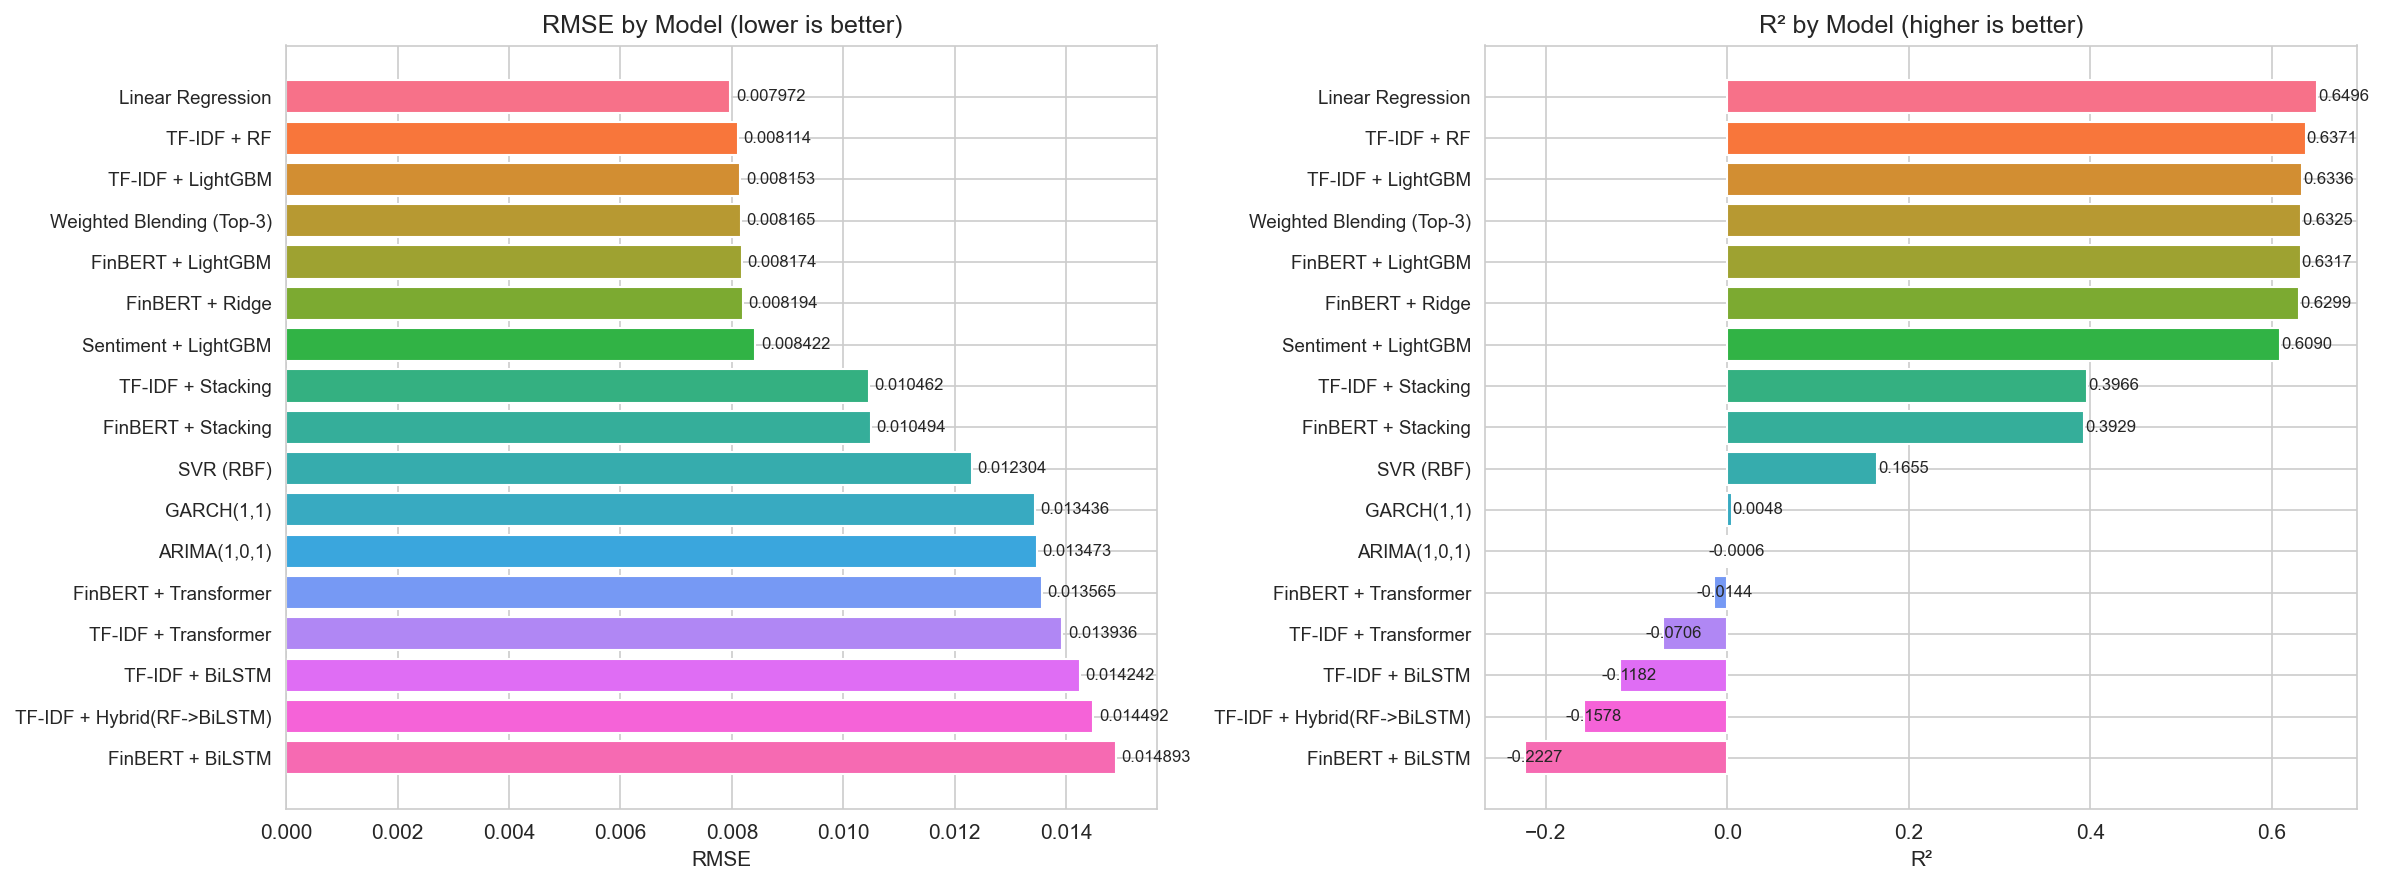

Saved: figures/fig1_performance_bars.png


In [28]:
# ============================================================
# FIGURE 1: Performance Bar Chart  (Grouped Bar: RMSE & MAE)
# ============================================================
# Exclude ablation-only models for main comparison
main_models = results_df[~results_df['Model'].str.contains('Fin Only|Naive')].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE bar
ax = axes[0]
colors = sns.color_palette("husl", len(main_models))
bars = ax.barh(range(len(main_models)), main_models['RMSE'].values, color=colors)
ax.set_yticks(range(len(main_models)))
ax.set_yticklabels(main_models['Model'].values, fontsize=9)
ax.set_xlabel('RMSE')
ax.set_title('RMSE by Model (lower is better)')
ax.invert_yaxis()
for i, v in enumerate(main_models['RMSE'].values):
    ax.text(v + 0.0001, i, f'{v:.6f}', va='center', fontsize=8)

# R² bar
ax = axes[1]
bars = ax.barh(range(len(main_models)), main_models['R2'].values, color=colors)
ax.set_yticks(range(len(main_models)))
ax.set_yticklabels(main_models['Model'].values, fontsize=9)
ax.set_xlabel('R²')
ax.set_title('R² by Model (higher is better)')
ax.invert_yaxis()
for i, v in enumerate(main_models['R2'].values):
    ax.text(v + 0.001 if v > 0 else v - 0.02, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig1_performance_bars.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig1_performance_bars.png")

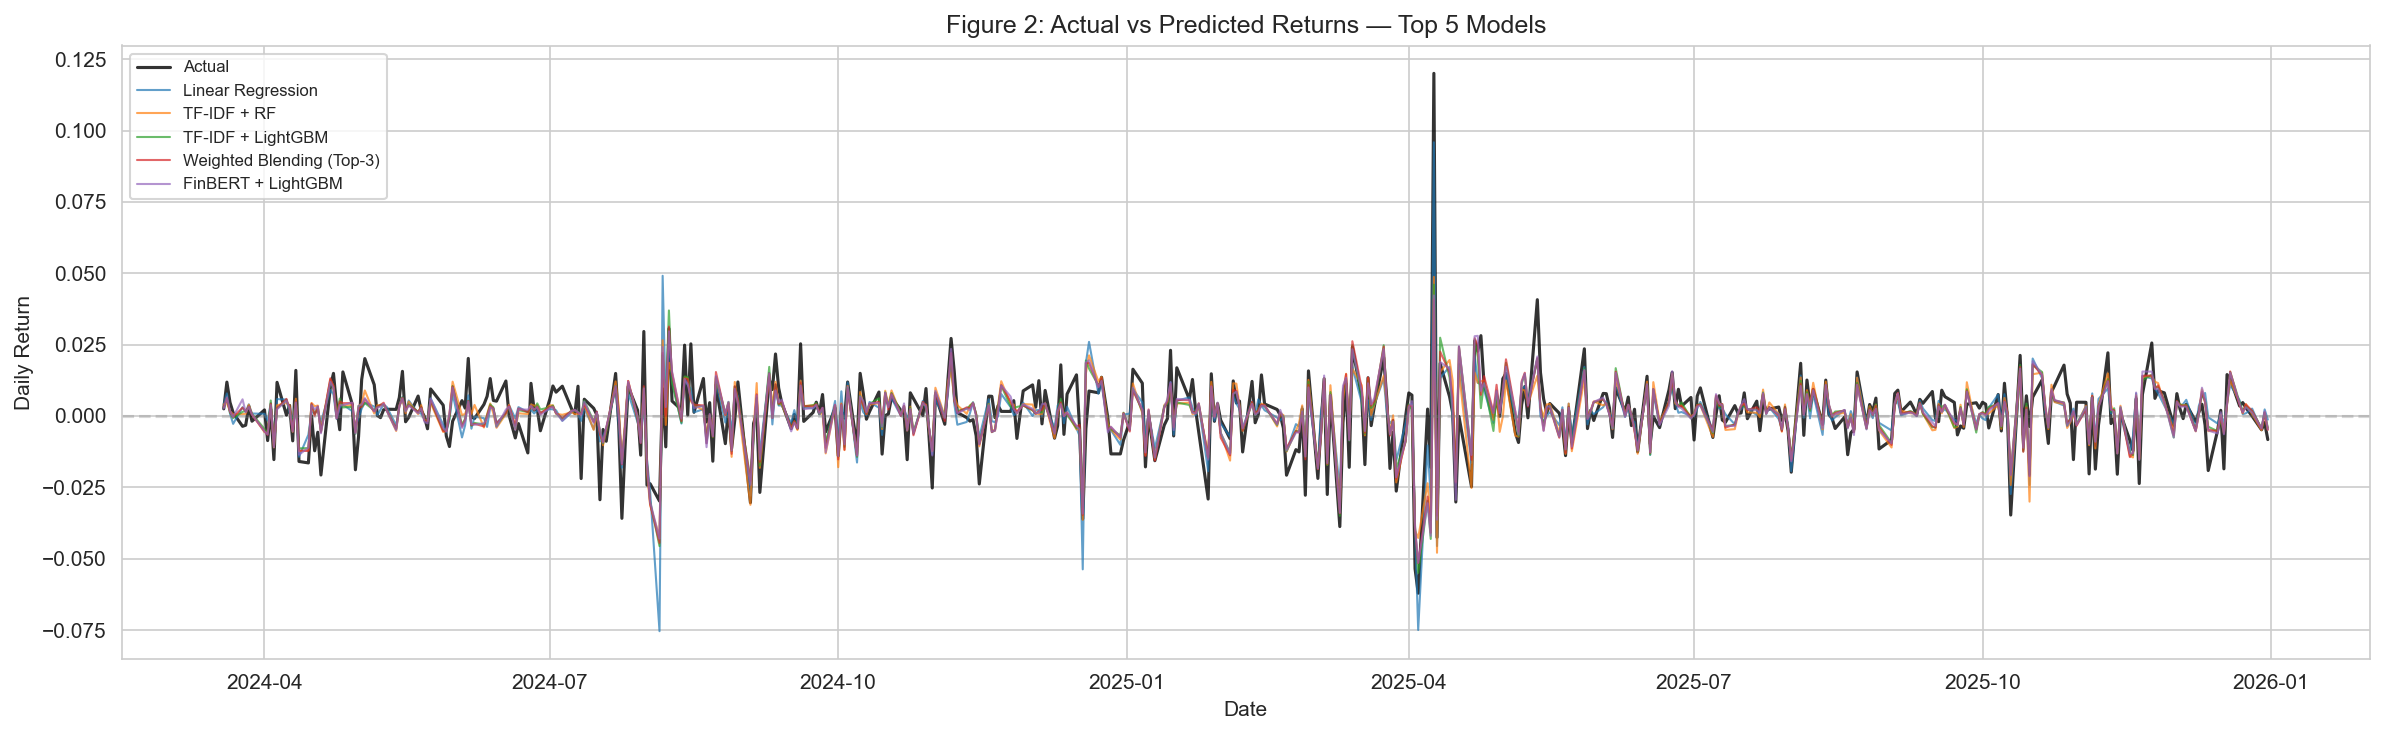

Saved: figures/fig2_actual_vs_predicted.png


In [29]:
# ============================================================
# FIGURE 2: Actual vs Predicted  (Top-5 Models on Test Set)
# ============================================================
top5 = results_df[~results_df['Model'].str.contains('Fin Only|Naive')].head(5)
top5_names = top5['Model'].tolist()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_dates[:n_test], y_test[:n_test], label='Actual', color='black',
        linewidth=1.5, alpha=0.8)

cmap = plt.cm.tab10
for idx, name in enumerate(top5_names):
    pred = predictions_dict[name][:n_test]
    ax.plot(test_dates[:n_test], pred, label=name, linewidth=1.0,
            alpha=0.7, color=cmap(idx))

ax.set_xlabel('Date')
ax.set_ylabel('Daily Return')
ax.set_title('Figure 2: Actual vs Predicted Returns — Top 5 Models')
ax.legend(fontsize=8, loc='upper left')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig2_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig2_actual_vs_predicted.png")

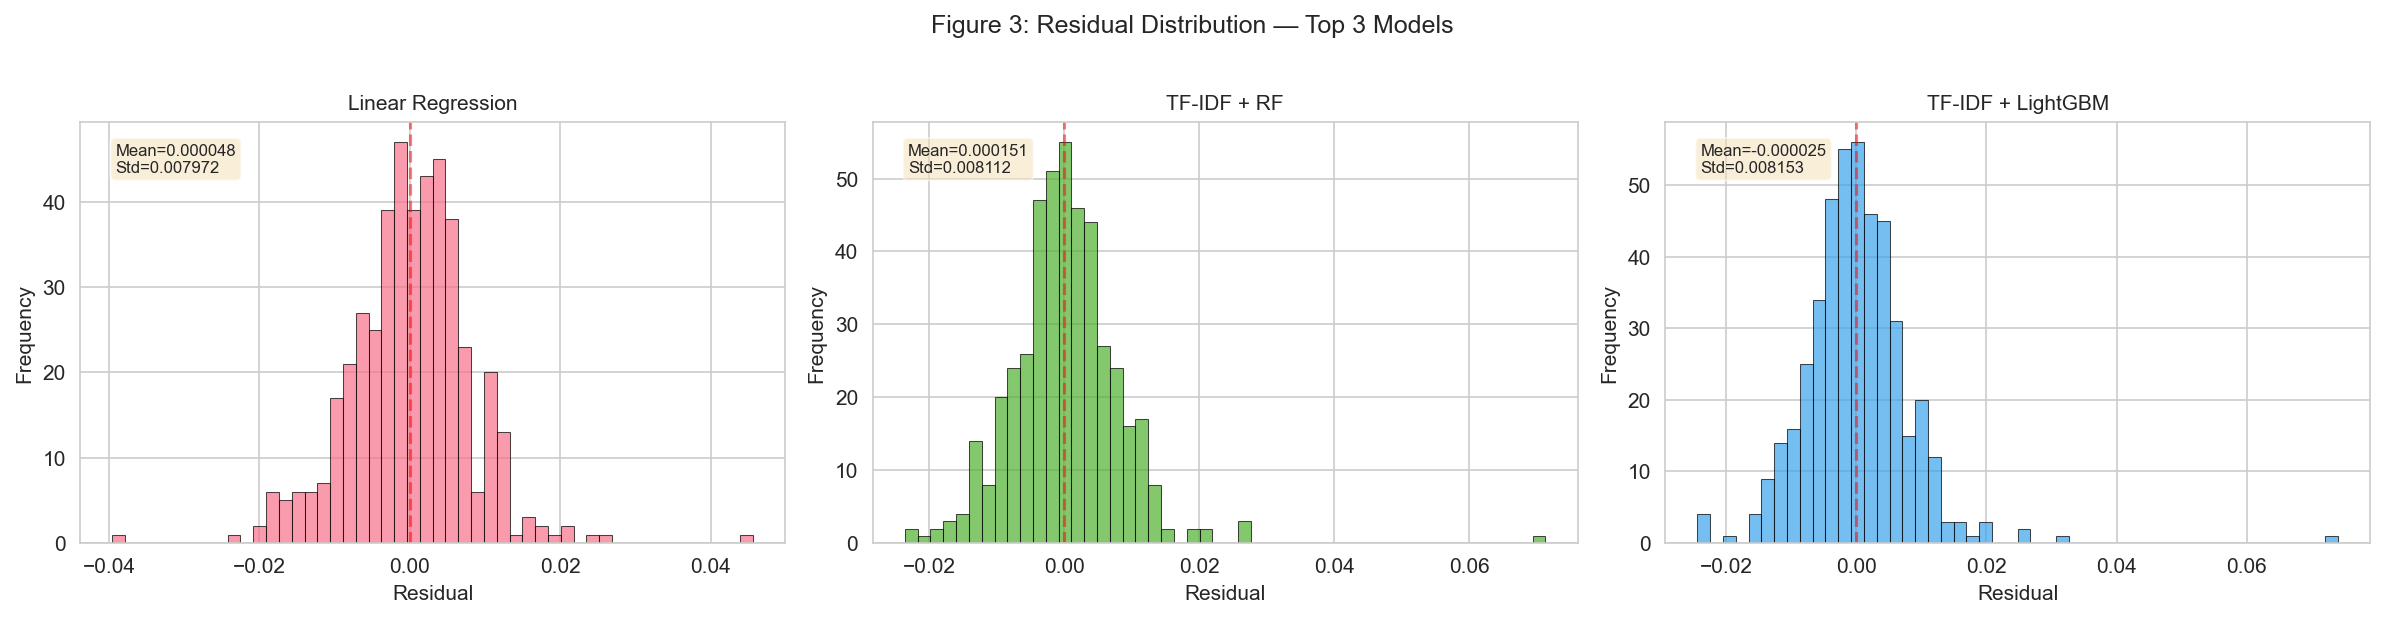

Saved: figures/fig3_residuals.png


In [30]:
# ============================================================
# FIGURE 3: Residual Distribution  (Top-3 Models)
# ============================================================
top3_names = results_df[~results_df['Model'].str.contains('Fin Only|Naive')].head(3)['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, name in enumerate(top3_names):
    pred = predictions_dict[name][:n_test]
    residuals = y_test[:n_test] - pred
    ax = axes[idx]
    ax.hist(residuals, bins=50, color=sns.color_palette("husl", 3)[idx],
            alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Frequency')
    m = np.mean(residuals)
    s = np.std(residuals)
    ax.text(0.05, 0.95, f'Mean={m:.6f}\nStd={s:.6f}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Figure 3: Residual Distribution — Top 3 Models', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig3_residuals.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig3_residuals.png")

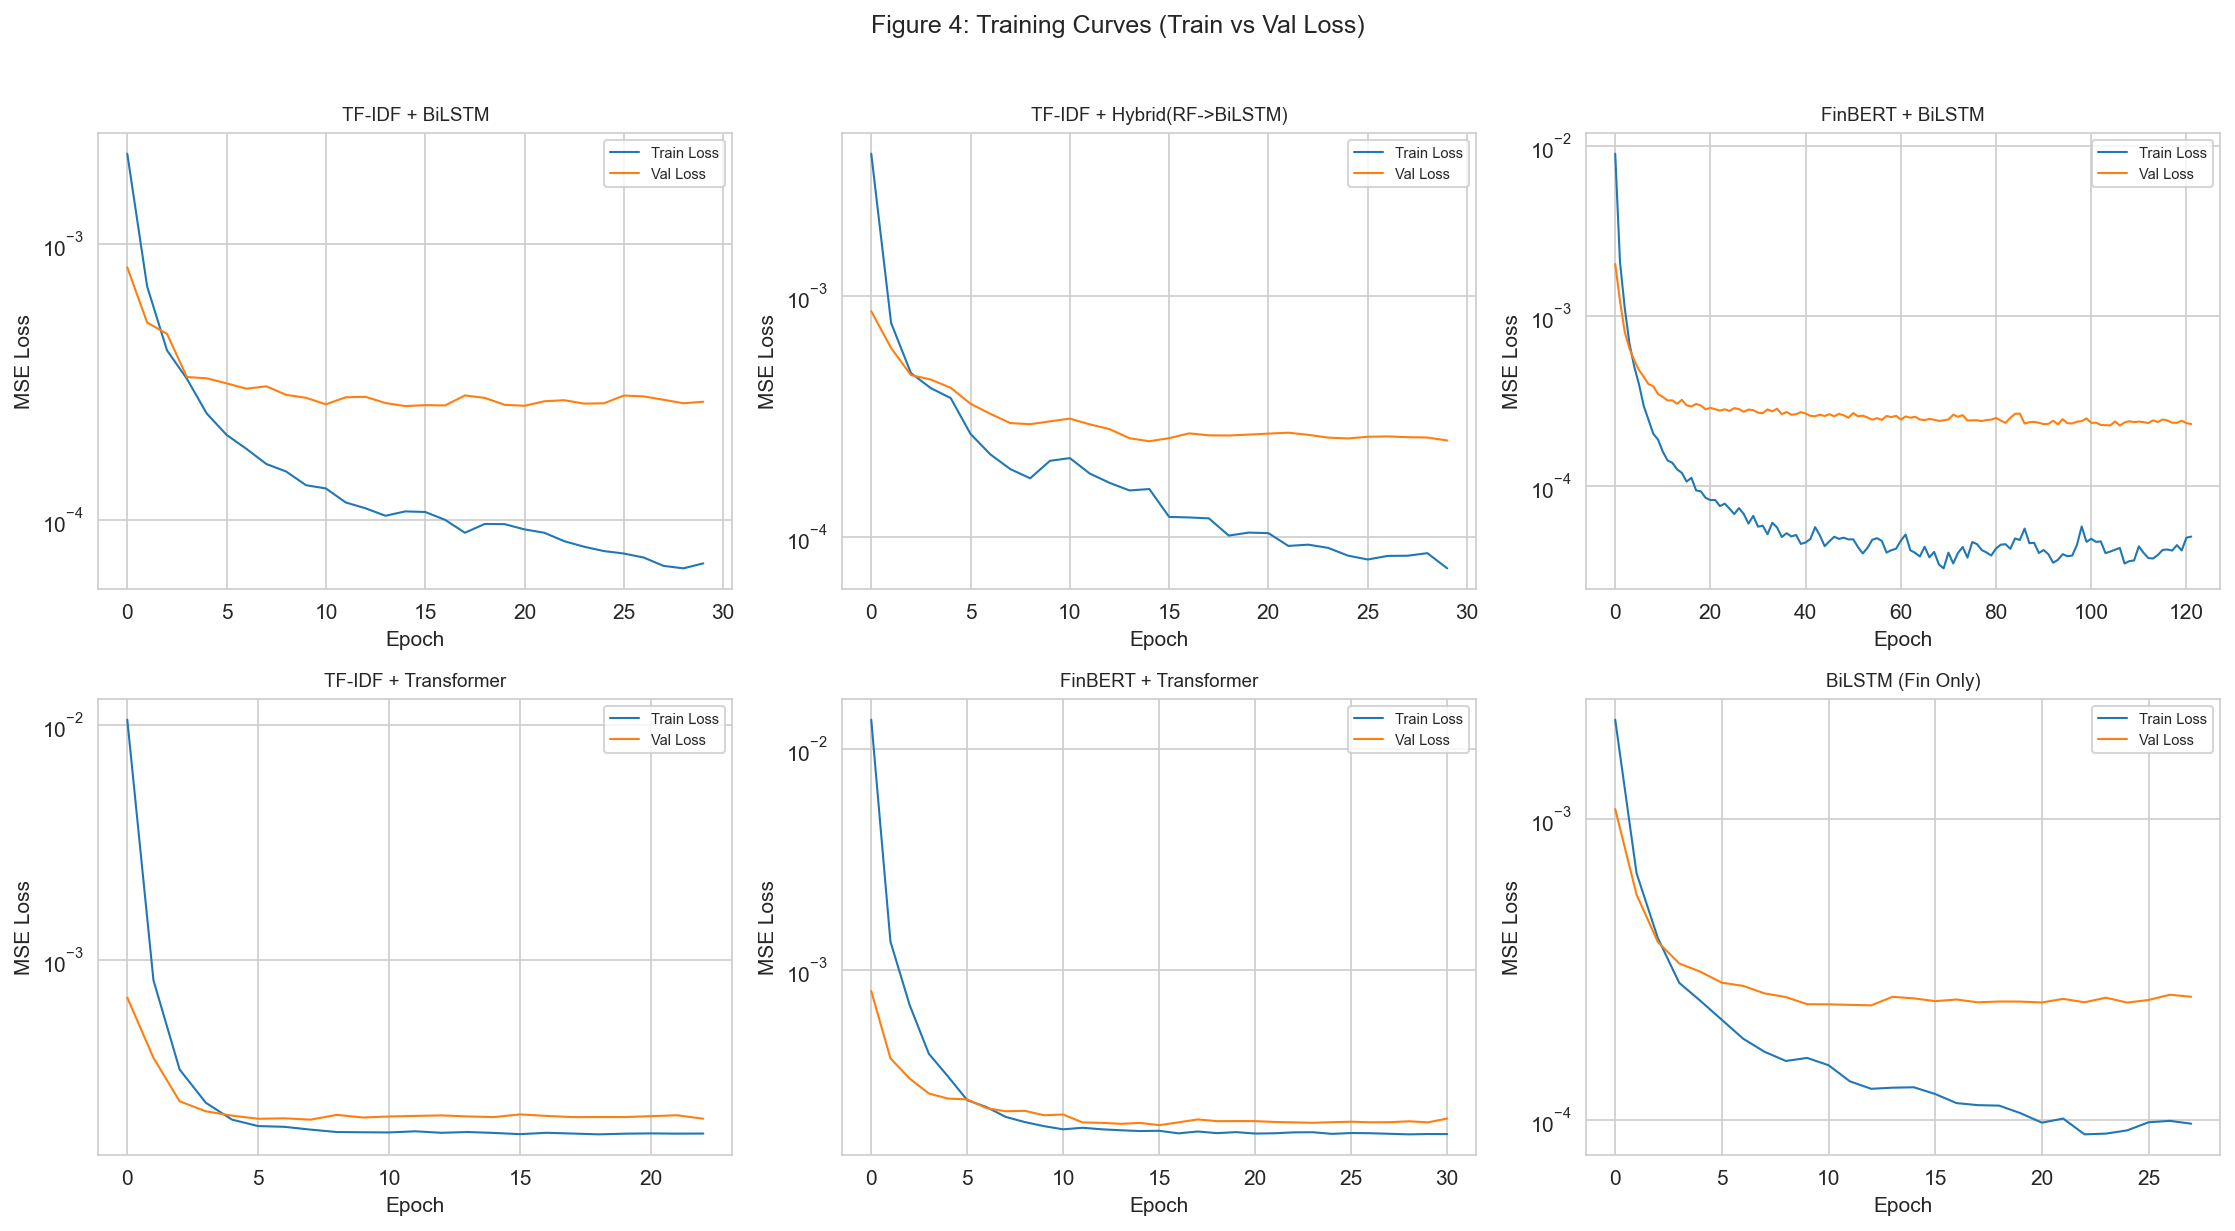

Saved: figures/fig4_training_curves.png


In [31]:
# ============================================================
# FIGURE 4: Training Curves  (Loss over Epochs)
# ============================================================
nn_models = [k for k in training_histories.keys()]
n_nn = len(nn_models)

if n_nn > 0:
    cols = min(3, n_nn)
    rows = (n_nn + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if n_nn == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for idx, name in enumerate(nn_models):
        ax = axes[idx]
        h = training_histories[name]
        ax.plot(h['loss'], label='Train Loss', linewidth=1)
        ax.plot(h['val_loss'], label='Val Loss', linewidth=1)
        ax.set_title(name, fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=7)
        ax.set_yscale('log')

    # Hide unused subplots
    for idx in range(n_nn, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Figure 4: Training Curves (Train vs Val Loss)', y=1.02)
    plt.tight_layout()
    plt.savefig('figures/fig4_training_curves.png', bbox_inches='tight')
    plt.show()
    print("Saved: figures/fig4_training_curves.png")
else:
    print("No neural network training histories to plot.")

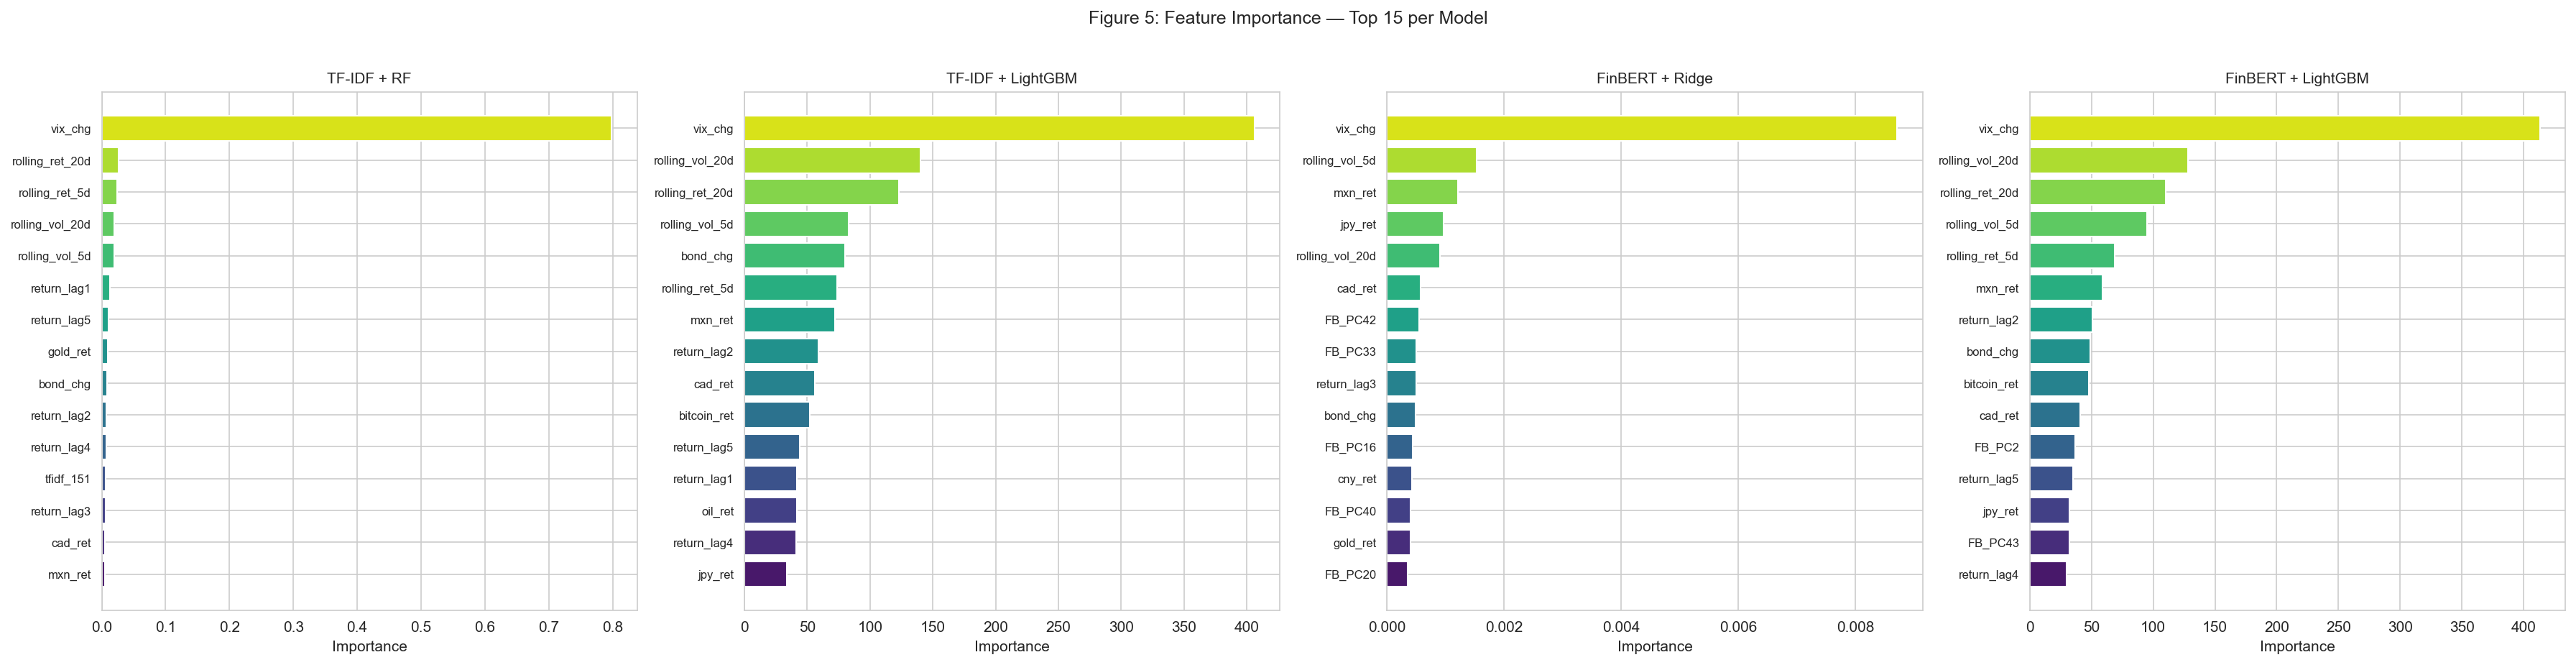

Saved: figures/fig5_feature_importance.png


In [32]:
# ============================================================
# FIGURE 5: Feature Importance  (Top Features per Model)
# ============================================================
fi_models = list(feature_importances_dict.keys())
n_fi = len(fi_models)

if n_fi > 0:
    fig, axes = plt.subplots(1, n_fi, figsize=(6 * n_fi, 6))
    if n_fi == 1:
        axes = [axes]

    for idx, name in enumerate(fi_models):
        ax = axes[idx]
        feat_names, feat_vals = feature_importances_dict[name]
        # Top 15
        top_idx = np.argsort(feat_vals)[-15:]
        top_names = [feat_names[i] for i in top_idx]
        top_vals  = feat_vals[top_idx]

        ax.barh(range(len(top_names)), top_vals,
                color=sns.color_palette("viridis", len(top_names)))
        ax.set_yticks(range(len(top_names)))
        ax.set_yticklabels(top_names, fontsize=8)
        ax.set_xlabel('Importance')
        ax.set_title(name, fontsize=10)

    plt.suptitle('Figure 5: Feature Importance — Top 15 per Model', y=1.02)
    plt.tight_layout()
    plt.savefig('figures/fig5_feature_importance.png', bbox_inches='tight')
    plt.show()
    print("Saved: figures/fig5_feature_importance.png")
else:
    print("No feature importance data.")

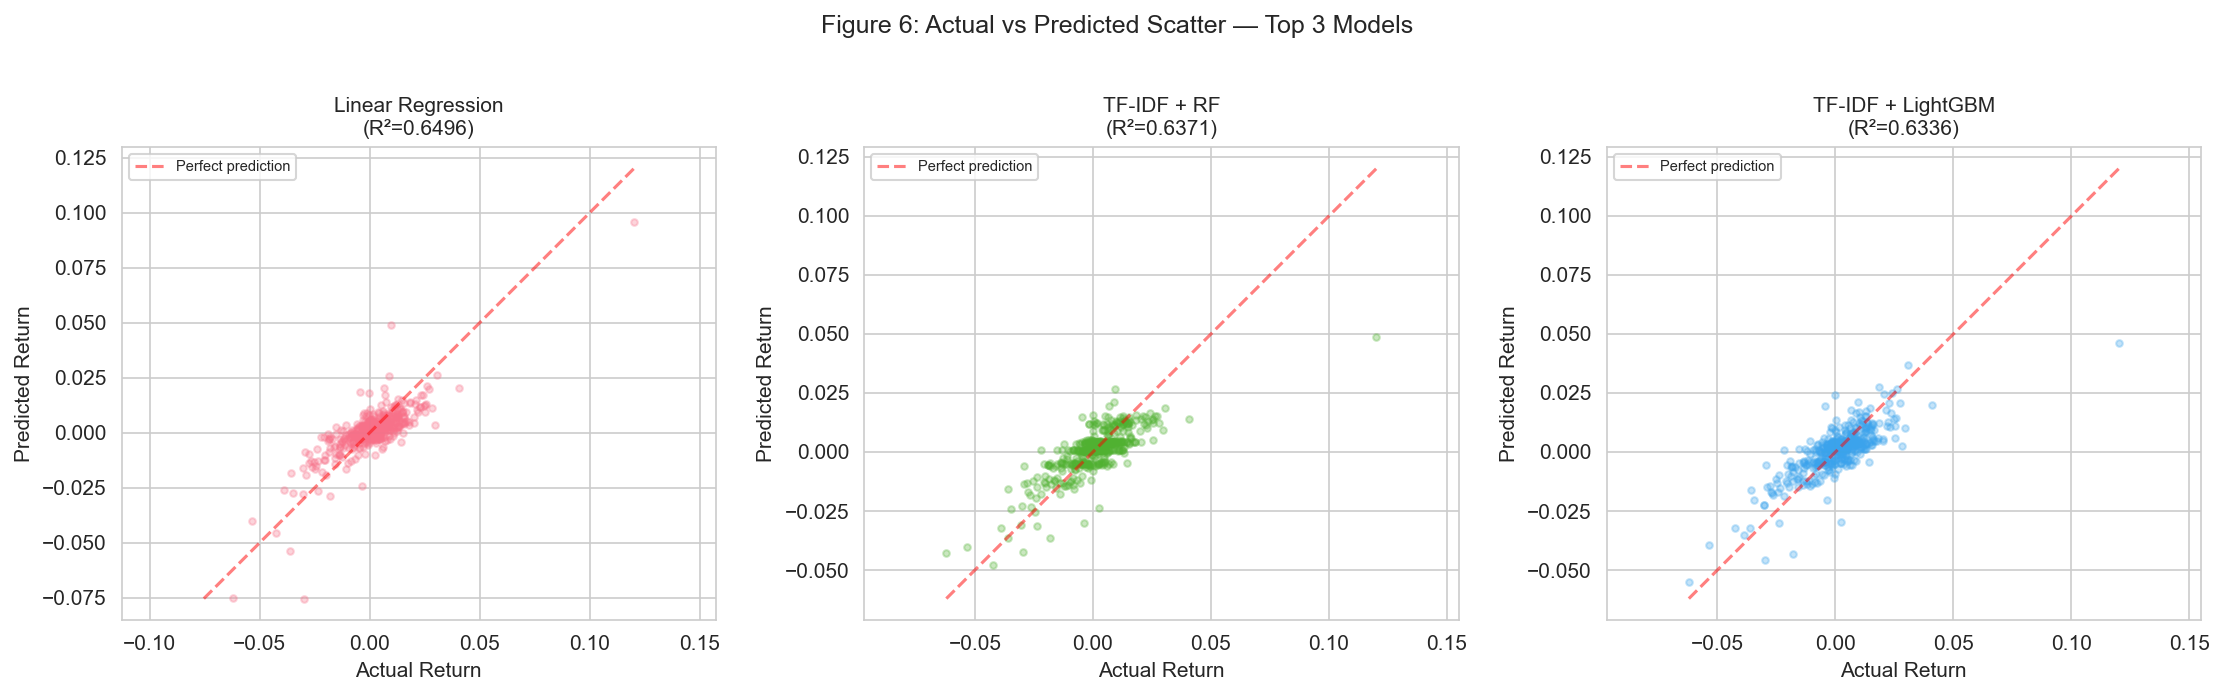

Saved: figures/fig6_scatter.png


In [33]:
# ============================================================
# FIGURE 6: Scatter Plot  (Actual vs Predicted, Top-3)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, name in enumerate(top3_names):
    ax = axes[idx]
    pred = predictions_dict[name][:n_test]
    actual = y_test[:n_test]

    ax.scatter(actual, pred, alpha=0.3, s=10,
               color=sns.color_palette("husl", 3)[idx])
    # 45-degree line
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect prediction')
    ax.set_xlabel('Actual Return')
    ax.set_ylabel('Predicted Return')
    ax.set_title(f'{name}\n(R²={r2_score(actual, pred):.4f})', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('Figure 6: Actual vs Predicted Scatter — Top 3 Models', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig6_scatter.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig6_scatter.png")

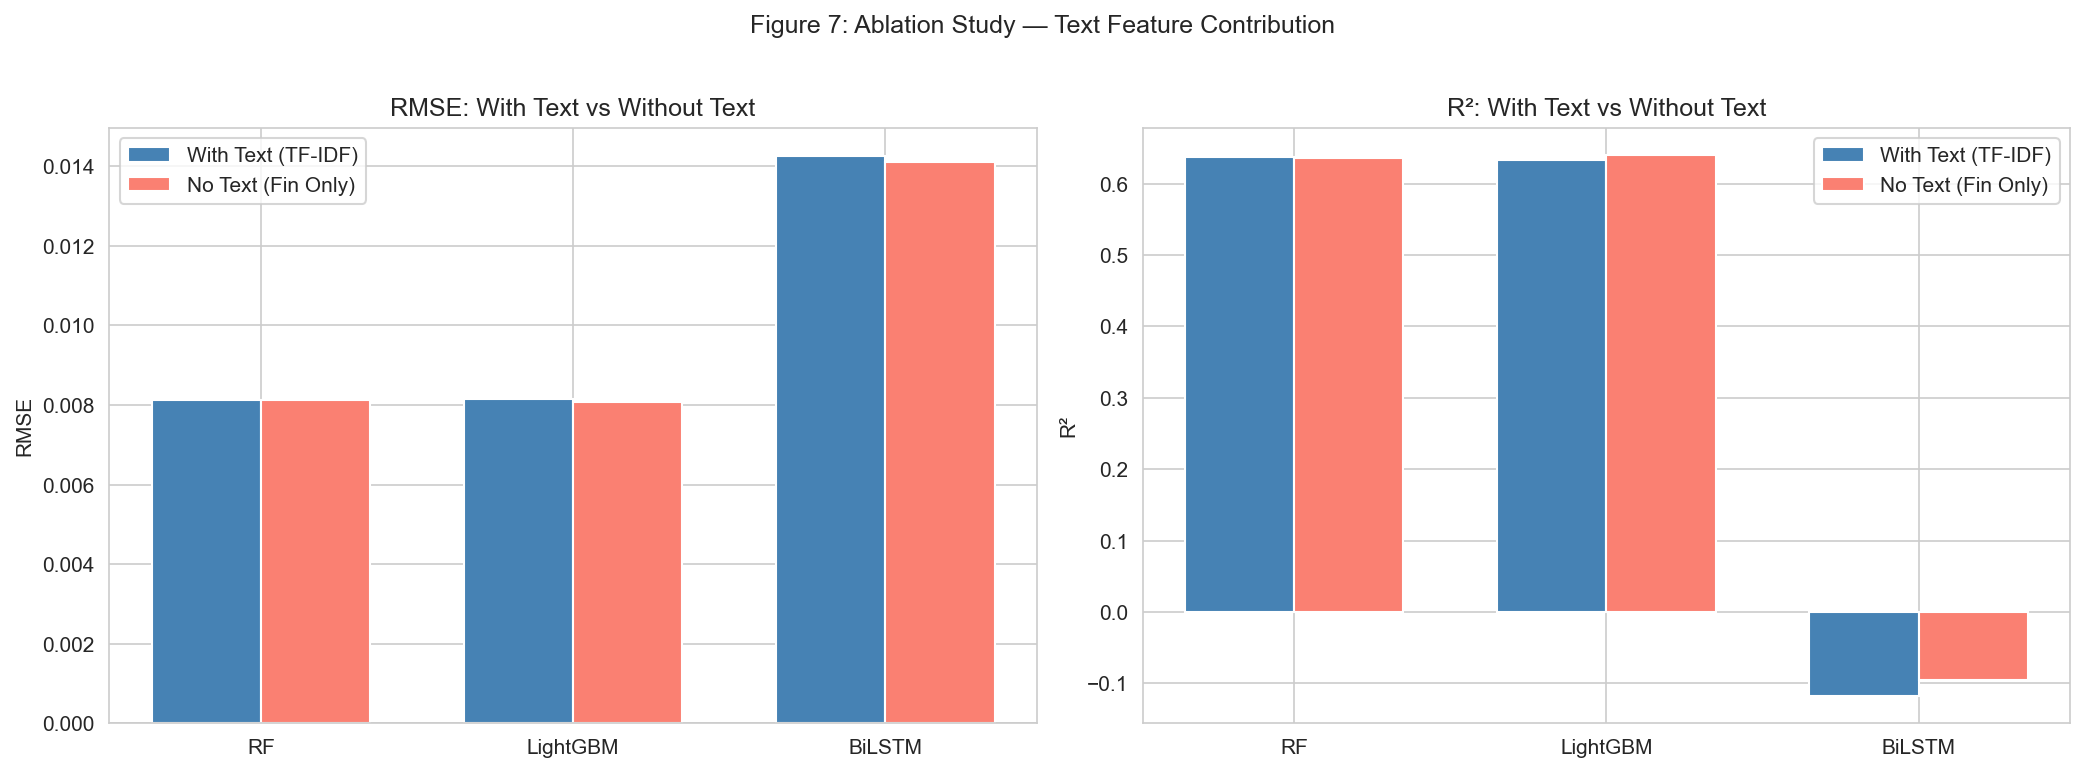

Saved: figures/fig7_ablation.png


In [34]:
# ============================================================
# FIGURE 7: Ablation Study Chart
# ============================================================
# Compare: with text vs without text for each algorithm
ablation_pairs = [
    ("RF",       "TF-IDF + RF",       "RF (Fin Only)"),
    ("LightGBM", "TF-IDF + LightGBM", "LightGBM (Fin Only)"),
    ("BiLSTM",   "TF-IDF + BiLSTM",   "BiLSTM (Fin Only)"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
ax = axes[0]
x = np.arange(len(ablation_pairs))
width = 0.35

rmse_with = []
rmse_without = []
labels = []
for label, with_name, without_name in ablation_pairs:
    r_with = results_df[results_df['Model'] == with_name]
    r_without = results_df[results_df['Model'] == without_name]
    if len(r_with) > 0 and len(r_without) > 0:
        rmse_with.append(r_with['RMSE'].values[0])
        rmse_without.append(r_without['RMSE'].values[0])
        labels.append(label)

x = np.arange(len(labels))
ax.bar(x - width/2, rmse_with, width, label='With Text (TF-IDF)', color='steelblue')
ax.bar(x + width/2, rmse_without, width, label='No Text (Fin Only)', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('RMSE')
ax.set_title('RMSE: With Text vs Without Text')
ax.legend()

# R² comparison
ax = axes[1]
r2_with = []
r2_without = []
for label, with_name, without_name in ablation_pairs:
    r_with = results_df[results_df['Model'] == with_name]
    r_without = results_df[results_df['Model'] == without_name]
    if len(r_with) > 0 and len(r_without) > 0:
        r2_with.append(r_with['R2'].values[0])
        r2_without.append(r_without['R2'].values[0])

ax.bar(x - width/2, r2_with, width, label='With Text (TF-IDF)', color='steelblue')
ax.bar(x + width/2, r2_without, width, label='No Text (Fin Only)', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('R²')
ax.set_title('R²: With Text vs Without Text')
ax.legend()

plt.suptitle('Figure 7: Ablation Study — Text Feature Contribution', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig7_ablation.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig7_ablation.png")

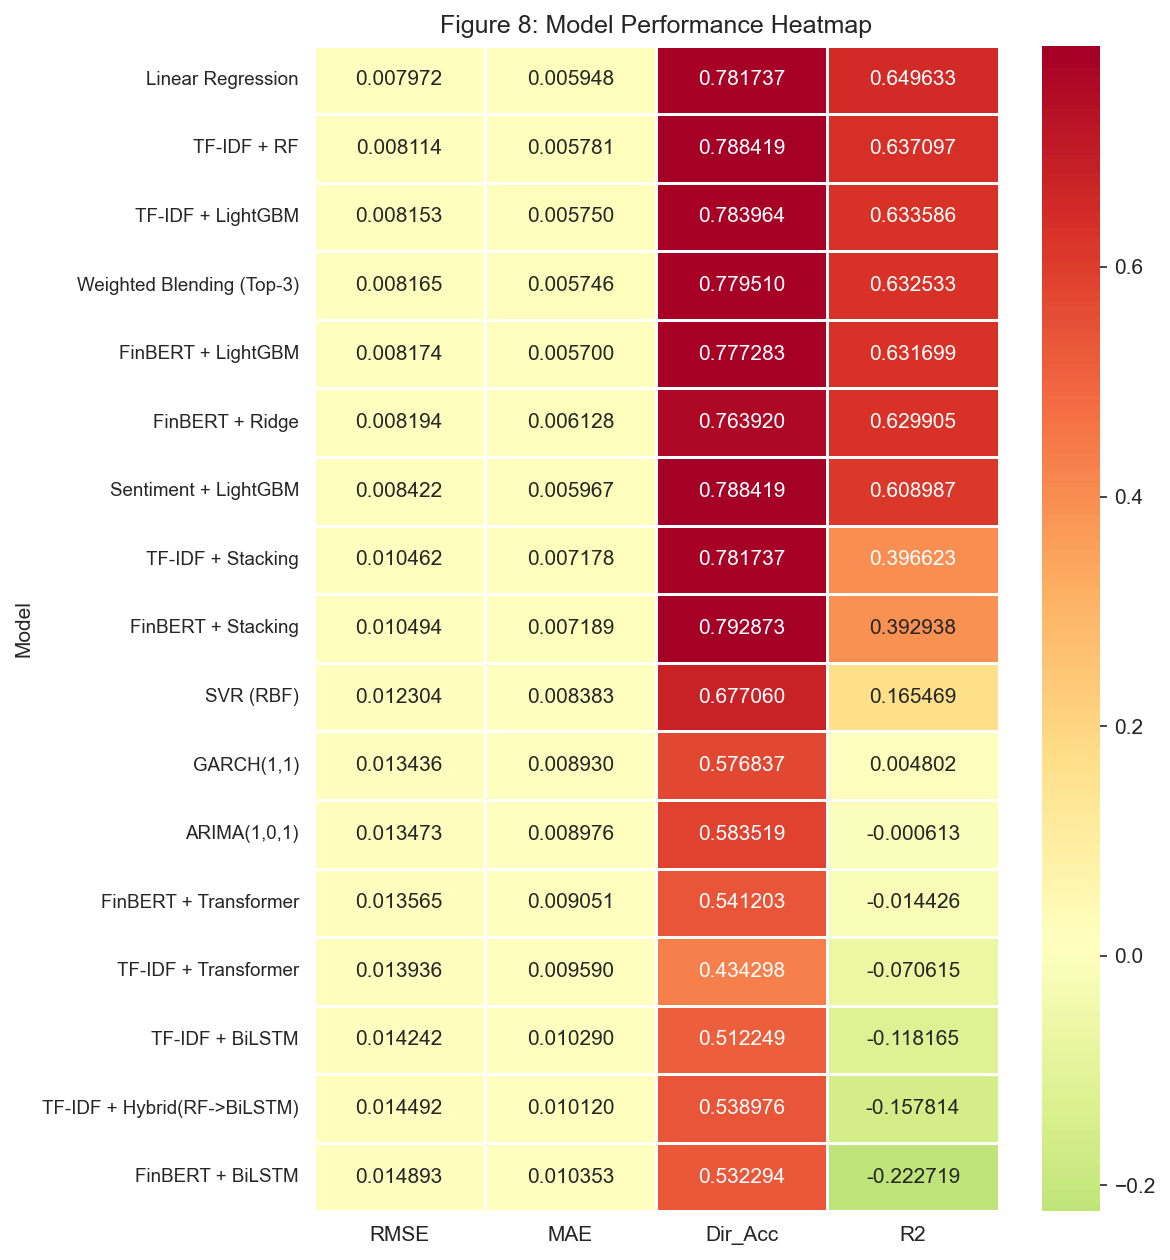

Saved: figures/fig8_heatmap.png


In [35]:
# ============================================================
# FIGURE 8: Performance Heatmap
# ============================================================
# Prepare heatmap data (main models only)
hm_df = results_df[~results_df['Model'].str.contains('Fin Only|Naive')].copy()
hm_data = hm_df.set_index('Model')[['RMSE', 'MAE', 'Dir_Acc', 'R2']]

fig, ax = plt.subplots(figsize=(8, max(6, len(hm_data) * 0.5)))
sns.heatmap(hm_data.astype(float), annot=True, fmt='.6f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5, center=hm_data['RMSE'].median())
ax.set_title('Figure 8: Model Performance Heatmap')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig8_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig8_heatmap.png")

In [36]:
# ============================================================
# SAVE ALL RESULTS
# ============================================================
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

# Full results table
results_df_final = pd.DataFrame(results_list).sort_values('RMSE').reset_index(drop=True)
results_df_final.index = results_df_final.index + 1
results_df_final.to_csv('results/model_comparison.csv', index=True, index_label='Rank')

# Best model highlight
best = results_df_final.iloc[0]
print(f"\n*** BEST MODEL: {best['Model']} ***")
print(f"    RMSE = {best['RMSE']:.6f}")
print(f"    MAE  = {best['MAE']:.6f}")
print(f"    Dir_Acc = {best['Dir_Acc']:.4f}")
print(f"    R²      = {best['R2']:.4f}")

# Save predictions
pred_df = pd.DataFrame(predictions_dict)
pred_df.insert(0, 'Date', test_dates[:len(pred_df)])
pred_df.insert(1, 'Actual', y_test[:len(pred_df)])
pred_df.to_csv('results/all_predictions.csv', index=False)

print(f"\nFiles saved:")
print(f"  results/model_comparison.csv")
print(f"  results/all_predictions.csv")
print(f"  figures/fig1~fig8 (.png)")
print(f"\nTotal models evaluated: {len(results_df_final)}")
print("=" * 80)

# Display final table
results_df_final[['Model', 'Text_Rep', 'RMSE', 'MAE', 'Dir_Acc', 'R2']]

FINAL SUMMARY

*** BEST MODEL: Linear Regression ***
    RMSE = 0.007972
    MAE  = 0.005948
    Dir_Acc = 0.7817
    R²      = 0.6496

Files saved:
  results/model_comparison.csv
  results/all_predictions.csv
  figures/fig1~fig8 (.png)

Total models evaluated: 21


,Model,Text_Rep,RMSE,MAE,Dir_Acc,R2
1,Linear Regression,None,0.007972,0.005948,0.781737,0.649633
2,LightGBM (Fin Only),None,0.008082,0.005714,0.775056,0.639954
3,TF-IDF + RF,TF-IDF,0.008114,0.005781,0.788419,0.637097
4,RF (Fin Only),None,0.008128,0.005787,0.788419,0.635799
5,TF-IDF + LightGBM,TF-IDF,0.008153,0.005750,0.783964,0.633586
6,Weighted Blending (Top-3),Mixed,0.008165,0.005746,0.779510,0.632533
7,FinBERT + LightGBM,FinBERT,0.008174,0.005700,0.777283,0.631699
8,FinBERT + Ridge,FinBERT,0.008194,0.006128,0.763920,0.629905
9,Sentiment + LightGBM,Sentiment,0.008422,0.005967,0.788419,0.608987
10,TF-IDF + Stacking,TF-IDF,0.010462,0.007178,0.781737,0.396623


## 10. Walk-Forward Validation (Robustness Check)

In [37]:
# ============================================================
# Walk-Forward Validation: Expanding Window (3 folds)
# ============================================================
print("=" * 80)
print("WALK-FORWARD VALIDATION")
print("=" * 80)

from sklearn.model_selection import TimeSeriesSplit

n_total = len(df)
wf_tscv = TimeSeriesSplit(n_splits=5)
wf_results = {name: [] for name in ['RF', 'LightGBM', 'Ridge']}

for fold, (tr_idx, te_idx) in enumerate(wf_tscv.split(df)):
    X_wf_tr = np.hstack([
        tfidf_vec.transform(df.iloc[tr_idx]['Headline_clean']).toarray(),
        scaler.transform(df.iloc[tr_idx][fin_return_cols])
    ])
    X_wf_te = np.hstack([
        tfidf_vec.transform(df.iloc[te_idx]['Headline_clean']).toarray(),
        scaler.transform(df.iloc[te_idx][fin_return_cols])
    ])
    y_wf_tr = df.iloc[tr_idx][TARGET_COL].values
    y_wf_te = df.iloc[te_idx][TARGET_COL].values

    # RF
    rf_wf = RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1)
    rf_wf.fit(X_wf_tr, y_wf_tr)
    pred_rf = rf_wf.predict(X_wf_te)
    wf_results['RF'].append({
        'fold': fold + 1,
        'RMSE': np.sqrt(mean_squared_error(y_wf_te, pred_rf)),
        'R2': r2_score(y_wf_te, pred_rf),
        'Dir_Acc': np.mean(np.sign(y_wf_te) == np.sign(pred_rf))
    })

    # LightGBM
    lgb_wf = lgb.LGBMRegressor(**best_lgbm_params, random_state=SEED, verbose=-1, n_jobs=-1)
    lgb_wf.fit(X_wf_tr, y_wf_tr)
    pred_lgb = lgb_wf.predict(X_wf_te)
    wf_results['LightGBM'].append({
        'fold': fold + 1,
        'RMSE': np.sqrt(mean_squared_error(y_wf_te, pred_lgb)),
        'R2': r2_score(y_wf_te, pred_lgb),
        'Dir_Acc': np.mean(np.sign(y_wf_te) == np.sign(pred_lgb))
    })

    # Ridge
    ridge_wf = Ridge(alpha=best_ridge_alpha)
    ridge_wf.fit(X_wf_tr, y_wf_tr)
    pred_ridge = ridge_wf.predict(X_wf_te)
    wf_results['Ridge'].append({
        'fold': fold + 1,
        'RMSE': np.sqrt(mean_squared_error(y_wf_te, pred_ridge)),
        'R2': r2_score(y_wf_te, pred_ridge),
        'Dir_Acc': np.mean(np.sign(y_wf_te) == np.sign(pred_ridge))
    })

    print(f"  Fold {fold+1}: RF R2={wf_results['RF'][-1]['R2']:.4f}  "
          f"LGB R2={wf_results['LightGBM'][-1]['R2']:.4f}  "
          f"Ridge R2={wf_results['Ridge'][-1]['R2']:.4f}")

print("\n--- Walk-Forward Summary ---")
for model_name, folds in wf_results.items():
    rmses = [f['RMSE'] for f in folds]
    r2s = [f['R2'] for f in folds]
    dirs = [f['Dir_Acc'] for f in folds]
    print(f"  {model_name:12s}: RMSE={np.mean(rmses):.6f}±{np.std(rmses):.6f}  "
          f"R2={np.mean(r2s):.4f}±{np.std(r2s):.4f}  "
          f"Dir={np.mean(dirs):.4f}±{np.std(dirs):.4f}")

# Save walk-forward results
wf_rows = []
for model_name, folds in wf_results.items():
    for f in folds:
        wf_rows.append({'Model': model_name, **f})
pd.DataFrame(wf_rows).to_csv('results/walk_forward_validation.csv', index=False)
print("\nSaved: results/walk_forward_validation.csv")

WALK-FORWARD VALIDATION
  Fold 1: RF R2=0.4697  LGB R2=0.4734  Ridge R2=0.4706
  Fold 2: RF R2=0.6291  LGB R2=0.6171  Ridge R2=0.5695
  Fold 3: RF R2=0.5238  LGB R2=0.5140  Ridge R2=0.5803
  Fold 4: RF R2=0.4735  LGB R2=0.4493  Ridge R2=0.3953
  Fold 5: RF R2=0.6190  LGB R2=0.6248  Ridge R2=0.6245

--- Walk-Forward Summary ---
  RF          : RMSE=0.009159±0.002587  R2=0.5430±0.0690  Dir=0.7602±0.0233
  LightGBM    : RMSE=0.009247±0.002674  R2=0.5357±0.0726  Dir=0.7582±0.0263
  Ridge       : RMSE=0.009283±0.002575  R2=0.5280±0.0833  Dir=0.7446±0.0315

Saved: results/walk_forward_validation.csv


## 11. News Lag Analysis

NEWS LAG ANALYSIS
  Lag=0: RMSE=0.008114  R2=0.6371  Dir_Acc=0.7884
  Lag=1: RMSE=0.008210  R2=0.6284  Dir_Acc=0.7906
  Lag=2: RMSE=0.008069  R2=0.6411  Dir_Acc=0.7884

Saved: results/news_lag_analysis.csv


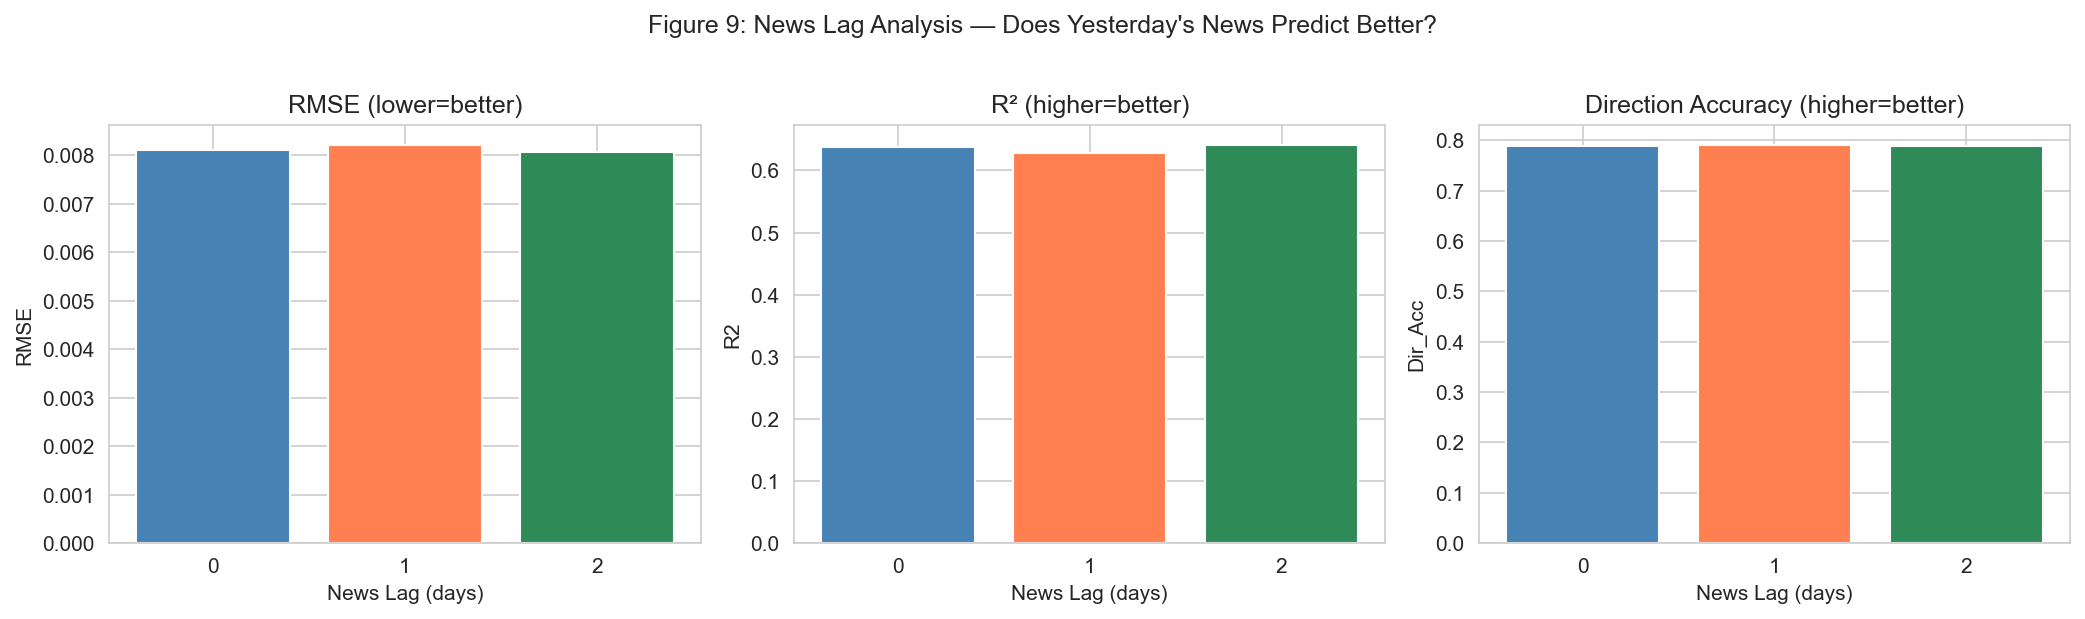

Saved: figures/fig9_news_lag.png


In [38]:
# ============================================================
# News Lag Experiment: Does t-1 day news predict t-day returns better?
# ============================================================
print("=" * 80)
print("NEWS LAG ANALYSIS")
print("=" * 80)

# Create lagged text features (shift headlines by 1 and 2 days)
lag_results = []

for lag in [0, 1, 2]:
    df_lag = df.copy()
    if lag > 0:
        df_lag['Headline_clean'] = df_lag['Headline_clean'].shift(lag)
        df_lag = df_lag.dropna().reset_index(drop=True)

    n_lag = len(df_lag)
    tr_end_lag, va_end_lag = temporal_split_indices(n_lag, TRAIN_RATIO, VAL_RATIO)
    train_lag = df_lag.iloc[:tr_end_lag]
    val_lag   = df_lag.iloc[tr_end_lag:va_end_lag]
    test_lag  = df_lag.iloc[va_end_lag:]

    # TF-IDF (refit for this lag)
    tfidf_lag = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,
                                 min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF)
    tfidf_lag.fit(train_lag['Headline_clean'])

    X_tr_lag = np.hstack([
        tfidf_lag.transform(train_lag['Headline_clean']).toarray(),
        scaler.transform(train_lag[fin_return_cols])
    ])
    X_te_lag = np.hstack([
        tfidf_lag.transform(test_lag['Headline_clean']).toarray(),
        scaler.transform(test_lag[fin_return_cols])
    ])
    y_tr_lag = train_lag[TARGET_COL].values
    y_te_lag = test_lag[TARGET_COL].values

    rf_lag = RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1)
    rf_lag.fit(X_tr_lag, y_tr_lag)
    pred_lag = rf_lag.predict(X_te_lag)

    lag_results.append({
        'Lag': lag,
        'RMSE': np.sqrt(mean_squared_error(y_te_lag, pred_lag)),
        'R2': r2_score(y_te_lag, pred_lag),
        'Dir_Acc': np.mean(np.sign(y_te_lag) == np.sign(pred_lag)),
        'N_test': len(y_te_lag)
    })
    print(f"  Lag={lag}: RMSE={lag_results[-1]['RMSE']:.6f}  R2={lag_results[-1]['R2']:.4f}  Dir_Acc={lag_results[-1]['Dir_Acc']:.4f}")

lag_df = pd.DataFrame(lag_results)
lag_df.to_csv('results/news_lag_analysis.csv', index=False)
print("\nSaved: results/news_lag_analysis.csv")

# Plot lag comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['RMSE', 'R2', 'Dir_Acc']
titles = ['RMSE (lower=better)', 'R² (higher=better)', 'Direction Accuracy (higher=better)']
for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(lag_df['Lag'].astype(str), lag_df[metric], color=['steelblue', 'coral', 'seagreen'])
    ax.set_xlabel('News Lag (days)')
    ax.set_ylabel(metric)
    ax.set_title(title)
plt.suptitle('Figure 9: News Lag Analysis — Does Yesterday\'s News Predict Better?', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig9_news_lag.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig9_news_lag.png")

## 12. Statistical Significance Tests

In [39]:
# ============================================================
# 12-1. Paired Bootstrap Test (Top-5 models)
# ============================================================
print("=" * 80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 80)

def paired_bootstrap_test(actual, pred_a, pred_b, n_bootstrap=10000, seed=42):
    """Paired bootstrap test: H0: MSE(A) = MSE(B). Returns (delta_mse, p_value)."""
    rng = np.random.RandomState(seed)
    n = len(actual)
    err_a = (actual - pred_a) ** 2
    err_b = (actual - pred_b) ** 2
    delta_obs = np.mean(err_a) - np.mean(err_b)  # negative = A is better
    count = 0
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, size=n)
        d = np.mean(err_a[idx]) - np.mean(err_b[idx])
        if delta_obs <= 0:
            if d >= 0: count += 1
        else:
            if d <= 0: count += 1
    return delta_obs, count / n_bootstrap

def diebold_mariano_test(actual, pred_a, pred_b):
    """Diebold-Mariano test for equal predictive accuracy."""
    from scipy import stats
    e_a = actual - pred_a
    e_b = actual - pred_b
    d = e_a**2 - e_b**2  # loss differential
    n = len(d)
    d_bar = np.mean(d)
    # Newey-West variance estimate (lag=int(n^(1/3)))
    max_lag = int(np.ceil(n**(1/3)))
    gamma_0 = np.var(d)
    gamma_sum = 0
    for h in range(1, max_lag + 1):
        gamma_h = np.cov(d[h:], d[:-h])[0, 1]
        gamma_sum += 2 * (1 - h / (max_lag + 1)) * gamma_h
    var_d = (gamma_0 + gamma_sum) / n
    if var_d <= 0:
        return d_bar, 1.0
    dm_stat = d_bar / np.sqrt(var_d)
    p_val = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_val

# Top-5 model pairs — Bootstrap test
top5_models = results_df_final.head(5)['Model'].tolist()
print("\n--- Paired Bootstrap Test (top-5 models) ---")
bootstrap_rows = []
for i in range(len(top5_models)):
    for j in range(i + 1, len(top5_models)):
        m_a, m_b = top5_models[i], top5_models[j]
        if m_a in predictions_dict and m_b in predictions_dict:
            p_a = predictions_dict[m_a][:n_test]
            p_b = predictions_dict[m_b][:n_test]
            delta, pval = paired_bootstrap_test(y_test[:n_test], p_a, p_b)
            sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else 'n.s.'))
            bootstrap_rows.append({'Model A': m_a, 'Model B': m_b,
                                   'ΔMSE': f'{delta:.8f}', 'p-value': f'{pval:.4f}', 'Sig': sig})
            print(f"  {m_a:35s} vs {m_b:35s}  ΔMSE={delta:+.2e}  p={pval:.4f}  {sig}")

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.to_csv('results/bootstrap_significance.csv', index=False)
print("\nSaved: results/bootstrap_significance.csv")

STATISTICAL SIGNIFICANCE TESTS

--- Paired Bootstrap Test (top-5 models) ---
  Linear Regression                   vs LightGBM (Fin Only)                  ΔMSE=-1.76e-06  p=0.4862  n.s.
  Linear Regression                   vs TF-IDF + RF                          ΔMSE=-2.27e-06  p=0.4634  n.s.
  Linear Regression                   vs RF (Fin Only)                        ΔMSE=-2.51e-06  p=0.4546  n.s.
  Linear Regression                   vs TF-IDF + LightGBM                    ΔMSE=-2.91e-06  p=0.4489  n.s.
  LightGBM (Fin Only)                 vs TF-IDF + RF                          ΔMSE=-5.18e-07  p=0.4141  n.s.
  LightGBM (Fin Only)                 vs RF (Fin Only)                        ΔMSE=-7.54e-07  p=0.3800  n.s.
  LightGBM (Fin Only)                 vs TF-IDF + LightGBM                    ΔMSE=-1.16e-06  p=0.0679  *
  TF-IDF + RF                         vs RF (Fin Only)                        ΔMSE=-2.35e-07  p=0.2902  n.s.
  TF-IDF + RF                         vs TF-IDF + Ligh

In [40]:
# ============================================================
# 12-2. Diebold-Mariano Test (key comparisons)
# ============================================================
print("\n--- Diebold-Mariano Test ---")
dm_pairs = [
    # Text vs No-text comparisons
    ('TF-IDF + RF', 'RF (Fin Only)'),
    ('TF-IDF + LightGBM', 'LightGBM (Fin Only)'),
    ('FinBERT + LightGBM', 'LightGBM (Fin Only)'),
    ('TF-IDF + Stacking', 'LightGBM (Fin Only)'),
]

dm_rows = []
for m_a, m_b in dm_pairs:
    if m_a in predictions_dict and m_b in predictions_dict:
        p_a = predictions_dict[m_a][:n_test]
        p_b = predictions_dict[m_b][:n_test]
        dm_stat, dm_pval = diebold_mariano_test(y_test[:n_test], p_a, p_b)
        sig = '***' if dm_pval < 0.01 else ('**' if dm_pval < 0.05 else ('*' if dm_pval < 0.10 else 'n.s.'))
        dm_rows.append({'Model A': m_a, 'Model B': m_b,
                        'DM Stat': f'{dm_stat:.4f}', 'p-value': f'{dm_pval:.4f}', 'Sig': sig})
        print(f"  {m_a:35s} vs {m_b:25s}  DM={dm_stat:+.4f}  p={dm_pval:.4f}  {sig}")

dm_df = pd.DataFrame(dm_rows)
dm_df.to_csv('results/diebold_mariano.csv', index=False)
print("\nSaved: results/diebold_mariano.csv")


--- Diebold-Mariano Test ---
  TF-IDF + RF                         vs RF (Fin Only)              DM=-0.5405  p=0.5888  n.s.
  TF-IDF + LightGBM                   vs LightGBM (Fin Only)        DM=+1.6773  p=0.0935  *
  FinBERT + LightGBM                  vs LightGBM (Fin Only)        DM=+0.9125  p=0.3615  n.s.
  TF-IDF + Stacking                   vs LightGBM (Fin Only)        DM=+3.7840  p=0.0002  ***

Saved: results/diebold_mariano.csv


In [41]:
# ============================================================
# 12-3. Bootstrap Confidence Intervals for Best Model
# ============================================================
print("\n--- Bootstrap 95% CI for metrics ---")
best_model_name = results_df_final.iloc[0]['Model']
best_preds = predictions_dict[best_model_name][:n_test]
best_actual = y_test[:n_test]

rng = np.random.RandomState(42)
n_boot = 5000
boot_rmse, boot_r2, boot_dir = [], [], []

for _ in range(n_boot):
    idx = rng.randint(0, n_test, size=n_test)
    y_b = best_actual[idx]
    p_b = best_preds[idx]
    boot_rmse.append(np.sqrt(mean_squared_error(y_b, p_b)))
    boot_r2.append(r2_score(y_b, p_b))
    boot_dir.append(np.mean(np.sign(y_b) == np.sign(p_b)))

print(f"  {best_model_name}:")
print(f"    RMSE:    {np.mean(boot_rmse):.6f}  95% CI [{np.percentile(boot_rmse, 2.5):.6f}, {np.percentile(boot_rmse, 97.5):.6f}]")
print(f"    R2:      {np.mean(boot_r2):.4f}  95% CI [{np.percentile(boot_r2, 2.5):.4f}, {np.percentile(boot_r2, 97.5):.4f}]")
print(f"    Dir_Acc: {np.mean(boot_dir):.4f}  95% CI [{np.percentile(boot_dir, 2.5):.4f}, {np.percentile(boot_dir, 97.5):.4f}]")

ci_data = {
    'Metric': ['RMSE', 'R2', 'Dir_Acc'],
    'Mean': [np.mean(boot_rmse), np.mean(boot_r2), np.mean(boot_dir)],
    'CI_Lower': [np.percentile(boot_rmse, 2.5), np.percentile(boot_r2, 2.5), np.percentile(boot_dir, 2.5)],
    'CI_Upper': [np.percentile(boot_rmse, 97.5), np.percentile(boot_r2, 97.5), np.percentile(boot_dir, 97.5)],
}
pd.DataFrame(ci_data).to_csv('results/bootstrap_ci.csv', index=False)
print("Saved: results/bootstrap_ci.csv")


--- Bootstrap 95% CI for metrics ---
  Linear Regression:
    RMSE:    0.007953  95% CI [0.007156, 0.008855]
    R2:      0.6395  95% CI [0.5034, 0.7536]
    Dir_Acc: 0.7820  95% CI [0.7439, 0.8196]
Saved: results/bootstrap_ci.csv
